In [2]:
from IPython.display import display, HTML

display(HTML("""<style>.container {width: 300% !important;}</style>"""))

# Contents

# Part 1: Monitoring Alert Prediction

## 1. Exploratory Data Analysis
  Summary statistics and vidualizations

- Univariate analysis

- Missing value analysis and imputation  


## 2. Variable Selection
- Relavant feature engineered covariates with high correlation with the label

- Variable selection with cross validation under XGBoost model
  (LightGBM, LSTM, Time Series Model, Logistic Regression if time permitted)

## 3. Hyper Parameter Tuning 
- Time series cross validation

- Test error estimation from the best model

## 4. Test Error Estimation and Test Data Prediction 


Note - Post Submission Adjustment 

Adjustment of Codes for presentation purpose 
1. Retrived accidently deleted one code cell defining label variable  
   label = 'monitoring_alert' was missing 
3. Argument of mutual_info_classifi added  
   mutual_info_classifi(discrete_features = True, random_state = 42)

5. Improved the robustness of generate_final_selected_features function, allowing to handle different list of final features  
   hard coding -> use final_features list for feature engineering 
7. Bug fix: second step of backward variable selection wo_1 -> wo_2 -> wo_3 -> wo_4
   wo_2 was not obitained from wo_1, but from the initial final_features list

In [274]:
!pip install missingno > /dev/null 2>&1

In [4]:
!pip install xgboost > /dev/null 2>&1

In [5]:
!pip install  > /dev/null 2>&1

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [7]:
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

In [8]:
train = pd.read_csv('./dataset/train.csv')
test = pd.read_csv('./dataset/test.csv') 

In [9]:
train['Timestamp'] = pd.to_datetime(train['Timestamp'])
test['Timestamp'] = pd.to_datetime(test['Timestamp'])

# 1. EDA

## Understand the ditribution and trends of the variables of interest

In [10]:
display(train)

,Well_ID,Timestamp,Well_Operating_Status,Operational_Notes,Acoustic_Sensor_Env_dB,Ambient_Temperature_C,Casing_Pressure_SensorB_psi,Casing_Pressure_psi,Gearbox_Temperature_C,Gearbox_Vibration_mm_s,Hydraulic_Pressure_psi,Liquid_Flow_Rate_m3d,Lubrication_Status,Maintenance_Code,Motor_Power_kW,Polished_Rod_Vibration_mm_s,Seismic_Activity_Index,Stroke_Count_Today,Surface_Temperature_C,Tubing_Pressure_psi,VFD_Speed_pct,Monitoring_Alert
0,101,2023-01-01 00:00:00,Operating,NaN,49.227346,38.854665,50.897459,49.256230,67.367428,0.517302,30.170903,100.769050,NaN,NaN,48.550611,0.931715,10.000000,0,64.128805,197.273721,67.414439,0
1,101,2023-01-01 00:10:00,Operating,NaN,40.135114,36.311768,49.925884,48.734318,71.938489,0.481706,29.941944,99.845761,OK,NaN,50.020863,0.612326,10.007173,4,64.625281,201.903168,86.075002,0
2,101,2023-01-01 00:20:00,Operating,NaN,51.190784,38.751977,50.518002,49.636435,73.476772,0.607282,30.457478,103.088886,NaN,NaN,54.098816,0.663035,10.014345,8,62.624781,198.521759,73.653432,0
3,101,2023-01-01 00:30:00,Operating,NaN,45.558002,40.662510,51.624718,50.175814,72.928716,0.634475,31.381904,101.089720,NaN,NaN,50.049383,0.793380,10.021518,12,64.064278,204.559909,74.619125,0
4,101,2023-01-01 00:40:00,Operating,NaN,45.064738,37.945231,52.292048,49.078709,68.188568,0.477692,29.956880,98.444687,NaN,NaN,50.211552,0.827998,10.028690,16,63.969226,202.119309,76.773574,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40782,101,2023-10-19 22:10:00,Operating,NaN,47.006170,27.796794,51.779890,52.239625,78.502460,0.768184,29.735330,NaN,NaN,NaN,61.133114,0.664310,7.125267,532,62.972613,176.756007,69.007892,0
40783,101,2023-10-19 22:20:00,Operating,NaN,43.819635,29.067319,54.324112,51.889230,81.480187,0.556077,28.592517,95.504386,NaN,NaN,60.979545,0.901394,7.119402,536,64.057764,173.614143,82.765583,0
40784,101,2023-10-19 22:30:00,Operating,NaN,39.870584,26.203226,54.024466,53.048127,79.351414,0.600903,28.322948,99.713693,NaN,NaN,60.503607,1.183279,7.113542,540,63.447410,175.293320,80.269623,0
40785,101,2023-10-19 22:40:00,Operating,NaN,42.382936,29.882131,52.041916,52.188194,81.092399,0.678572,26.617094,98.897580,NaN,NaN,58.616558,0.925305,7.107688,544,64.604148,183.049578,75.368733,0


It is shown that Timestamp seems to be cleaned, possibly no duplication or missing. Operational_Notes looks to have many missing values. 

In [11]:
train['Well_ID'].value_counts()

Well_ID
101    40787
Name: count, dtype: int64

In [12]:
test['Well_ID'].value_counts()

Well_ID
101    10197
Name: count, dtype: int64

In [13]:
# Unique Well_ID -> removed
train.drop('Well_ID', axis=1, inplace = True)
test.drop('Well_ID', axis=1, inplace = True)

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40787 entries, 0 to 40786
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Timestamp                    40787 non-null  datetime64[ns]
 1   Well_Operating_Status        40787 non-null  object        
 2   Operational_Notes            1841 non-null   object        
 3   Acoustic_Sensor_Env_dB       40377 non-null  float64       
 4   Ambient_Temperature_C        40787 non-null  float64       
 5   Casing_Pressure_SensorB_psi  40787 non-null  float64       
 6   Casing_Pressure_psi          40787 non-null  float64       
 7   Gearbox_Temperature_C        39981 non-null  float64       
 8   Gearbox_Vibration_mm_s       40787 non-null  float64       
 9   Hydraulic_Pressure_psi       40787 non-null  float64       
 10  Liquid_Flow_Rate_m3d         39560 non-null  float64       
 11  Lubrication_Status           4009 non-nul

Numerical and categorical variables 

1. Split the data into a. data with only numerical variables, b. data with categorical variables.
2. Summary statistics, visualization of each row for a., b., and the label.

##### Both training data and test data were analyzed to confirm there has been no distribution shift and the inferences from training data set is reliable to the test data set. 

## Summary Statistics: Numerical Covariates

In [15]:
# Split num/categorical data sets separately
num_train = train.select_dtypes(include=['number', 'datetime']).copy()
num_test = test.select_dtypes(include=['number', 'datetime']).copy()


nonnum_train = train.select_dtypes(include=['object', 'category', 'datetime']).copy()
nonnum_test = test.select_dtypes(include=['object', 'category', 'datetime']).copy()

if 'Maintenance_Code' in num_train.columns:
    # Append numeric looking but more of categorical field 
    nonnum_train['Maintenance_Code'] = num_train['Maintenance_Code']
    nonnum_test['Maintenance_Code'] = num_test['Maintenance_Code']
    
    # Drop the field 
    num_train.drop('Maintenance_Code', axis=1, inplace=True)
    num_test.drop('Maintenance_Code', axis=1, inplace=True)

# Change col type to categories 
for colname in nonnum_train.columns:
    if colname == 'Timestamp':
        continue
    train[colname] = train[colname].astype('category')
    test[colname] = test[colname].astype('category')

In [16]:
nonnum_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40787 entries, 0 to 40786
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Timestamp              40787 non-null  datetime64[ns]
 1   Well_Operating_Status  40787 non-null  object        
 2   Operational_Notes      1841 non-null   object        
 3   Lubrication_Status     4009 non-null   object        
 4   Maintenance_Code       6195 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 1.6+ MB


In [17]:
num_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40787 entries, 0 to 40786
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Timestamp                    40787 non-null  datetime64[ns]
 1   Acoustic_Sensor_Env_dB       40377 non-null  float64       
 2   Ambient_Temperature_C        40787 non-null  float64       
 3   Casing_Pressure_SensorB_psi  40787 non-null  float64       
 4   Casing_Pressure_psi          40787 non-null  float64       
 5   Gearbox_Temperature_C        39981 non-null  float64       
 6   Gearbox_Vibration_mm_s       40787 non-null  float64       
 7   Hydraulic_Pressure_psi       40787 non-null  float64       
 8   Liquid_Flow_Rate_m3d         39560 non-null  float64       
 9   Motor_Power_kW               40787 non-null  float64       
 10  Polished_Rod_Vibration_mm_s  40787 non-null  float64       
 11  Seismic_Activity_Index       40787 non-nu

To check Timestamp is clean:

In [18]:
train['Timestamp'].value_counts()

Timestamp
2023-01-01 00:00:00    1
2023-07-14 15:50:00    1
2023-07-14 14:30:00    1
2023-07-14 14:40:00    1
2023-07-14 14:50:00    1
                      ..
2023-04-08 08:40:00    1
2023-04-08 08:50:00    1
2023-04-08 09:00:00    1
2023-04-08 09:10:00    1
2023-10-19 22:50:00    1
Name: count, Length: 40787, dtype: int64

In [19]:
if train['Timestamp'].nunique() == len(train):
    print('No duplication of missing on train data')

No duplication of missing on train data


In [20]:
if test['Timestamp'].nunique() == len(test):
    print('No duplication of missing on test data')

No duplication of missing on test data


Sample is generated every 10 minutes.

### Summary Statistics of numerical covariates from train and test data 

In [21]:
train.drop('Timestamp', axis=1).describe()

,Acoustic_Sensor_Env_dB,Ambient_Temperature_C,Casing_Pressure_SensorB_psi,Casing_Pressure_psi,Gearbox_Temperature_C,Gearbox_Vibration_mm_s,Hydraulic_Pressure_psi,Liquid_Flow_Rate_m3d,Motor_Power_kW,Polished_Rod_Vibration_mm_s,Seismic_Activity_Index,Stroke_Count_Today,Surface_Temperature_C,Tubing_Pressure_psi,VFD_Speed_pct,Monitoring_Alert
count,40377.000000,40787.000000,40787.000000,40787.000000,39981.000000,40787.000000,40787.000000,39560.000000,40787.000000,40787.000000,40787.000000,40787.000000,40192.000000,39794.000000,39970.000000,40787.000000
mean,45.032760,16.649570,52.017213,50.977222,74.606506,0.536923,28.661963,96.564020,54.320140,0.770062,10.152590,285.921593,60.740131,187.605666,74.017577,0.095006
std,4.008191,12.161613,2.207906,1.812444,4.459383,0.099645,3.194772,11.888129,6.267621,0.176020,3.519258,166.256234,2.697658,21.244573,9.932950,0.293226
min,27.446367,-7.482692,37.762732,39.291829,33.425641,0.022700,-4.030941,-19.738754,2.208784,0.029961,5.000000,0.000000,34.951934,122.123059,-0.931659,0.000000
25%,42.347761,6.072449,50.708179,49.896200,72.628767,0.482230,28.162855,95.680093,52.902076,0.665284,6.654347,140.000000,59.399225,181.217049,71.474073,0.000000
50%,45.050711,14.810344,52.035401,51.010055,74.441966,0.540328,28.992607,97.935327,54.944160,0.774181,10.329700,284.000000,60.811601,187.521814,74.941348,0.000000
75%,47.746034,26.042869,53.363072,52.114756,76.880113,0.598432,29.825427,100.114266,56.819861,0.882495,13.647788,432.000000,62.264101,193.920106,78.334163,0.000000
max,64.470617,48.434472,107.039474,58.048367,136.535713,1.045505,34.008717,110.529178,75.742814,1.656087,15.000000,572.000000,73.586462,1183.873631,94.711603,1.000000


In [22]:
test.drop('Timestamp', axis=1).describe()

,Acoustic_Sensor_Env_dB,Ambient_Temperature_C,Casing_Pressure_SensorB_psi,Casing_Pressure_psi,Gearbox_Temperature_C,Gearbox_Vibration_mm_s,Hydraulic_Pressure_psi,Liquid_Flow_Rate_m3d,Motor_Power_kW,Polished_Rod_Vibration_mm_s,Seismic_Activity_Index,Stroke_Count_Today,Surface_Temperature_C,Tubing_Pressure_psi,VFD_Speed_pct
count,10105.000000,10197.000000,10197.000000,10197.000000,9998.000000,10197.000000,10197.000000,9917.000000,10197.000000,10197.000000,10197.000000,10197.000000,10039.000000,9934.000000,10009.000000
mean,45.003968,33.420882,53.295175,52.244423,82.486703,0.593045,27.527529,94.060255,61.409776,0.862915,9.397033,286.264980,65.050646,172.264670,74.233544
std,4.079176,4.934893,2.062929,1.635617,4.304631,0.102392,2.800091,10.891772,6.678592,0.179975,3.539003,166.381226,2.719774,16.828009,9.470766
min,28.593664,16.239149,39.815607,39.682599,35.546725,0.028108,0.000000,-13.880767,4.203381,0.051252,5.000000,0.000000,36.285470,126.497509,-0.931659
25%,42.262269,30.001549,52.024572,51.229060,81.119621,0.537249,27.069328,93.087927,59.558520,0.756595,5.954915,144.000000,63.932287,170.034837,71.600200
50%,44.980103,33.894963,53.289967,52.242067,82.517642,0.594456,27.794726,95.299679,61.619953,0.863805,8.750994,288.000000,64.901408,172.670431,75.109837
75%,47.767021,37.052449,54.545456,53.301546,83.966331,0.651811,28.527335,97.384750,63.879328,0.970548,12.933120,432.000000,65.899270,175.120182,78.453064
max,62.057012,46.659348,96.943627,57.423304,136.335501,1.207194,31.988950,107.551253,80.993116,1.677935,15.000000,572.000000,79.133366,1135.576849,98.673141


In [23]:
summary_diff = train.drop(['Timestamp', 'Monitoring_Alert'], axis=1).describe() - test.drop('Timestamp', axis=1).describe()
summary_diff = summary_diff.loc[['mean', 'min', '50%', 'max', 'std']]
sorted_diff = summary_diff.loc[:, summary_diff.loc['mean'].abs().sort_values(ascending=False).index]

In [24]:
print('Train data min timestamp:', train['Timestamp'].min(),'Train data min timestamp:', train['Timestamp'].max())
print('Test data min timestamp:', test['Timestamp'].min(),'test data min timestamp:', test['Timestamp'].max())

Train data min timestamp: 2023-01-01 00:00:00 Train data min timestamp: 2023-10-19 22:50:00
Test data min timestamp: 2023-10-19 23:00:00 test data min timestamp: 2023-12-31 23:50:00


### Differences of the statistics between train and test data 
To make sure the assumption of identically distribution

In [25]:
sorted_diff

,Ambient_Temperature_C,Tubing_Pressure_psi,Gearbox_Temperature_C,Motor_Power_kW,Surface_Temperature_C,Liquid_Flow_Rate_m3d,Casing_Pressure_SensorB_psi,Casing_Pressure_psi,Hydraulic_Pressure_psi,Seismic_Activity_Index,Stroke_Count_Today,VFD_Speed_pct,Polished_Rod_Vibration_mm_s,Gearbox_Vibration_mm_s,Acoustic_Sensor_Env_dB
mean,-16.771312,15.340996,-7.880197,-7.089637,-4.310515,2.503765,-1.277961,-1.267201,1.134433,0.755557,-0.343387,-0.215967,-0.092853,-0.056122,0.028792
min,-23.721841,-4.374450,-2.121085,-1.994597,-1.333536,-5.857987,-2.052875,-0.390770,-4.030941,0.000000,0.000000,0.000000,-0.021291,-0.005409,-1.147296
50%,-19.084618,14.851383,-8.075675,-6.675793,-4.089807,2.635647,-1.254567,-1.232012,1.197881,1.578706,-4.000000,-0.168489,-0.089624,-0.054128,0.070607
max,1.775123,48.296781,0.200213,-5.250302,-5.546903,2.977925,10.095847,0.625063,2.019767,0.000000,0.000000,-3.961538,-0.021848,-0.161689,2.413605
std,7.226720,4.416564,0.154753,-0.410971,-0.022117,0.996357,0.144977,0.176828,0.394680,-0.019745,-0.124992,0.462184,-0.003955,-0.002747,-0.070984


'Ambient_Temperature_C', 'Tubing_Pressure_psi', 'Gearbox_Temperature_C', 'Motor_Power_kW', 'Surface_Temperature_C' variables has noticeable differences in their distributions between training and test data sets. The changes could be explained from the weather  changes, or there might be some unknown distribution shifts that accounts for the changes of the values of the variables.

## Visualization: Numerical Covariates

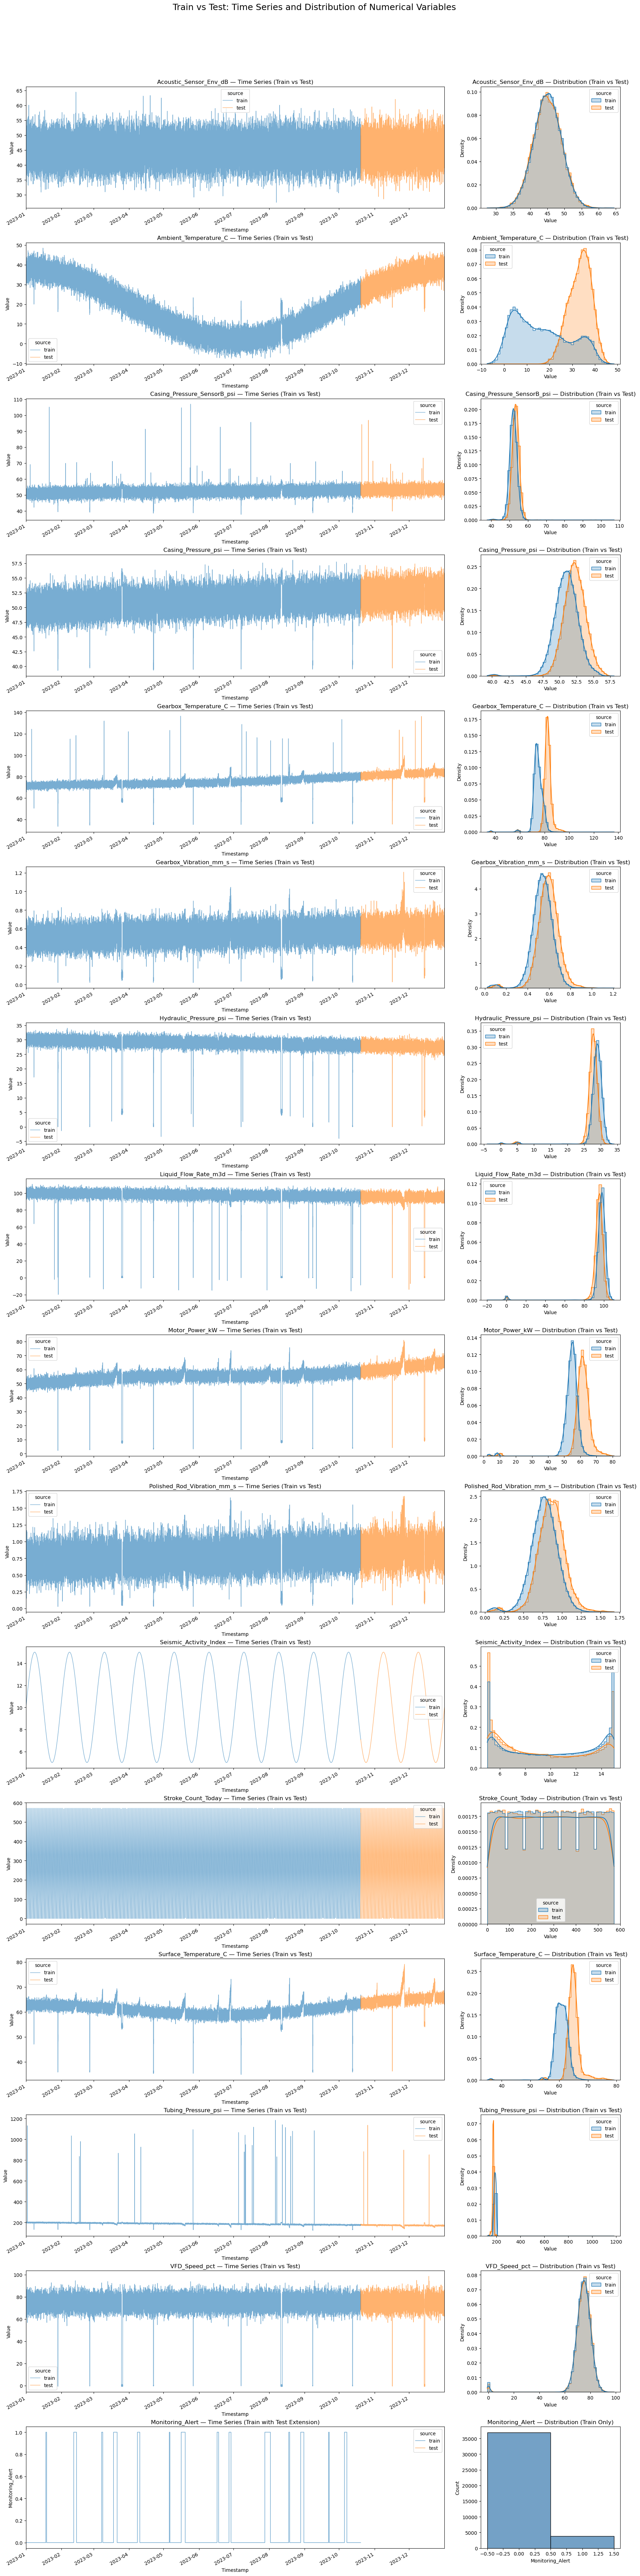

In [26]:
import matplotlib.gridspec as gridspec

# Add source column
train_tagged = num_train.copy()
train_tagged['source'] = 'train'

test_tagged = num_test.copy()
test_tagged['source'] = 'test'

# Combine train and test
combined = pd.concat([train_tagged, test_tagged], axis=0).reset_index(drop=True)

# Use the exact Timestamp range from combined (ensures consistent x-axis)
full_timestamps = combined['Timestamp'].drop_duplicates().sort_values()

min_time = full_timestamps.min()
max_time = full_timestamps.max()

# Extract Monitoring_Alert and reindex to match full timestamps
label_df = num_train[['Timestamp', 'Monitoring_Alert']].drop_duplicates()
label_df = label_df.set_index('Timestamp').sort_index()
label_full = label_df.reindex(full_timestamps)

# Reset index and tag source
label_full = label_full.reset_index().rename(columns={'index': 'Timestamp'})
train_timestamps = set(num_train['Timestamp'])
label_full['source'] = label_full['Timestamp'].isin(train_timestamps).map({True: 'train', False: 'test'})

# Extract numeric feature names (excluding Timestamp and Monitoring_Alert)
num_cols = [col for col in num_test.columns if col not in ['Timestamp', 'Monitoring_Alert']]
n_vars = len(num_cols)

# Create single figure with Monitoring_Alert row included
fig = plt.figure(figsize=(18, 4.5 * (n_vars + 1)), constrained_layout=True)
gs = gridspec.GridSpec(n_vars + 1, 2, width_ratios=[3, 1], figure=fig)

# --- Feature plots ---
for i, col in enumerate(num_cols):
    # Time series (left)
    ax_ts = fig.add_subplot(gs[i, 0])
    
    sns.lineplot(data=combined, x='Timestamp', y=col, hue='source', ax=ax_ts, alpha=0.6, linewidth=1)
    ax_ts.set_title(f'{col} — Time Series (Train vs Test)')
    ax_ts.set_xlabel('Timestamp')
    ax_ts.set_ylabel('Value')
    ax_ts.set_xlim([min_time, max_time])
    for label in ax_ts.get_xticklabels():
        label.set_rotation(30)
        label.set_horizontalalignment('right')

    # Distribution (right)
    ax_dist = fig.add_subplot(gs[i, 1])
    sns.histplot(
        data=combined, x=col, hue='source', kde=True, bins=50,
        ax=ax_dist, element='step', stat='density', common_norm=False
    )
    ax_dist.set_title(f'{col} — Distribution (Train vs Test)')
    ax_dist.set_xlabel('Value')
    ax_dist.set_ylabel('Density')

# --- Monitoring_Alert (last row) ---
ax_ts = fig.add_subplot(gs[n_vars, 0])
sns.lineplot(
    data=label_full,
    x='Timestamp',
    y='Monitoring_Alert',
    hue='source',
    ax=ax_ts,
    drawstyle='steps-post',
    alpha=0.7,
    linewidth=1
)
ax_ts.set_title('Monitoring_Alert — Time Series (Train with Test Extension)')
ax_ts.set_xlabel('Timestamp')
ax_ts.set_ylabel('Monitoring_Alert')
ax_ts.set_xlim([min_time, max_time]) 
for label in ax_ts.get_xticklabels():
    label.set_rotation(30)
    label.set_horizontalalignment('right')

ax_dist = fig.add_subplot(gs[n_vars, 1])
label_dist = label_full[label_full['source'] == 'train'].dropna(subset=['Monitoring_Alert'])
sns.histplot(
    data=label_dist,
    x='Monitoring_Alert',
    bins=2,
    discrete=True,
    color='steelblue',
    ax=ax_dist
)
ax_dist.set_title("Monitoring_Alert — Distribution (Train Only)")
ax_dist.set_xlabel("Monitoring_Alert")
ax_dist.set_ylabel("Count")

# Final layout with suptitle
fig.suptitle("Train vs Test: Time Series and Distribution of Numerical Variables", fontsize=18, y=1.03)
plt.show()

The variables trends over time and their distribution density is plotted. The colour difference in a plot indicates the source of the data.


Findings:

1. Training and test data set are consistent and there seem to be no extreme changes over time of variables.
2. The label is unbalanced.
3. There seem to be occasional and repeating extreme values over time on sesored data. Research on the extreme time series values is required.

## Summary Statistics: Categorical Data

In [27]:
# Categorical variables' marginal distribution comparison 
cat_cmpr_list = []
for colname in [col for col in nonnum_train.columns if col != 'Timestamp']:
    nn_tr_mr = nonnum_train[colname].value_counts(normalize=True).reset_index()
    nn_ts_mr =nonnum_test[colname].value_counts(normalize=True).reset_index()
    nn_tr_mr.rename(columns={'proportion':'Proportion (Training)'},inplace = True)
    nn_ts_mr.rename(columns={'proportion':'proportion (Test)'},inplace = True)
    cat_smmry_cmpr = nn_tr_mr.merge(nn_ts_mr, how = 'outer')
    cat_cmpr_list.append(cat_smmry_cmpr)

## Distributions of variables (training/test)

In [28]:
for i in range(len(cat_cmpr_list)):
    display(cat_cmpr_list[i])

,Well_Operating_Status,Proportion (Training),proportion (Test)
0,Maintenance,0.004609,0.001961
1,Operating,0.985412,0.987741
2,Standby,0.008434,0.009513
3,Startup,0.001545,0.000785


,Operational_Notes,Proportion (Training),proportion (Test)
0,Bringing online after workover,0.004889,0.002217
1,Checking surface equipment,0.002716,NaN
2,Confirming stroke length,0.003802,NaN
3,Flow consistent,0.030418,0.035477
4,Flow rate drop,0.048343,0.062084
5,Flowline pressured up,0.003802,NaN
6,Fluid level check,0.010320,0.004435
7,Fluid pound detected,0.047800,0.055432
8,Gas interference suspected,0.056491,0.050998
9,Gearbox oil change,0.008148,0.006652


,Lubrication_Status,Proportion (Training),proportion (Test)
0,Low,0.10676,0.102021
1,OK,0.89324,0.897979


,Maintenance_Code,Proportion (Training),proportion (Test)
0,501.0,0.503148,0.517906
1,502.0,0.196287,0.203168
2,610.0,0.151251,0.139118
3,705.0,0.095722,0.091598
4,999.0,0.053592,0.048209


Their distribution over their time period seems consistent.

## Visualization: Categorical Data 


The plot below illustrates the distributions and their changes over time of the variables of interest.

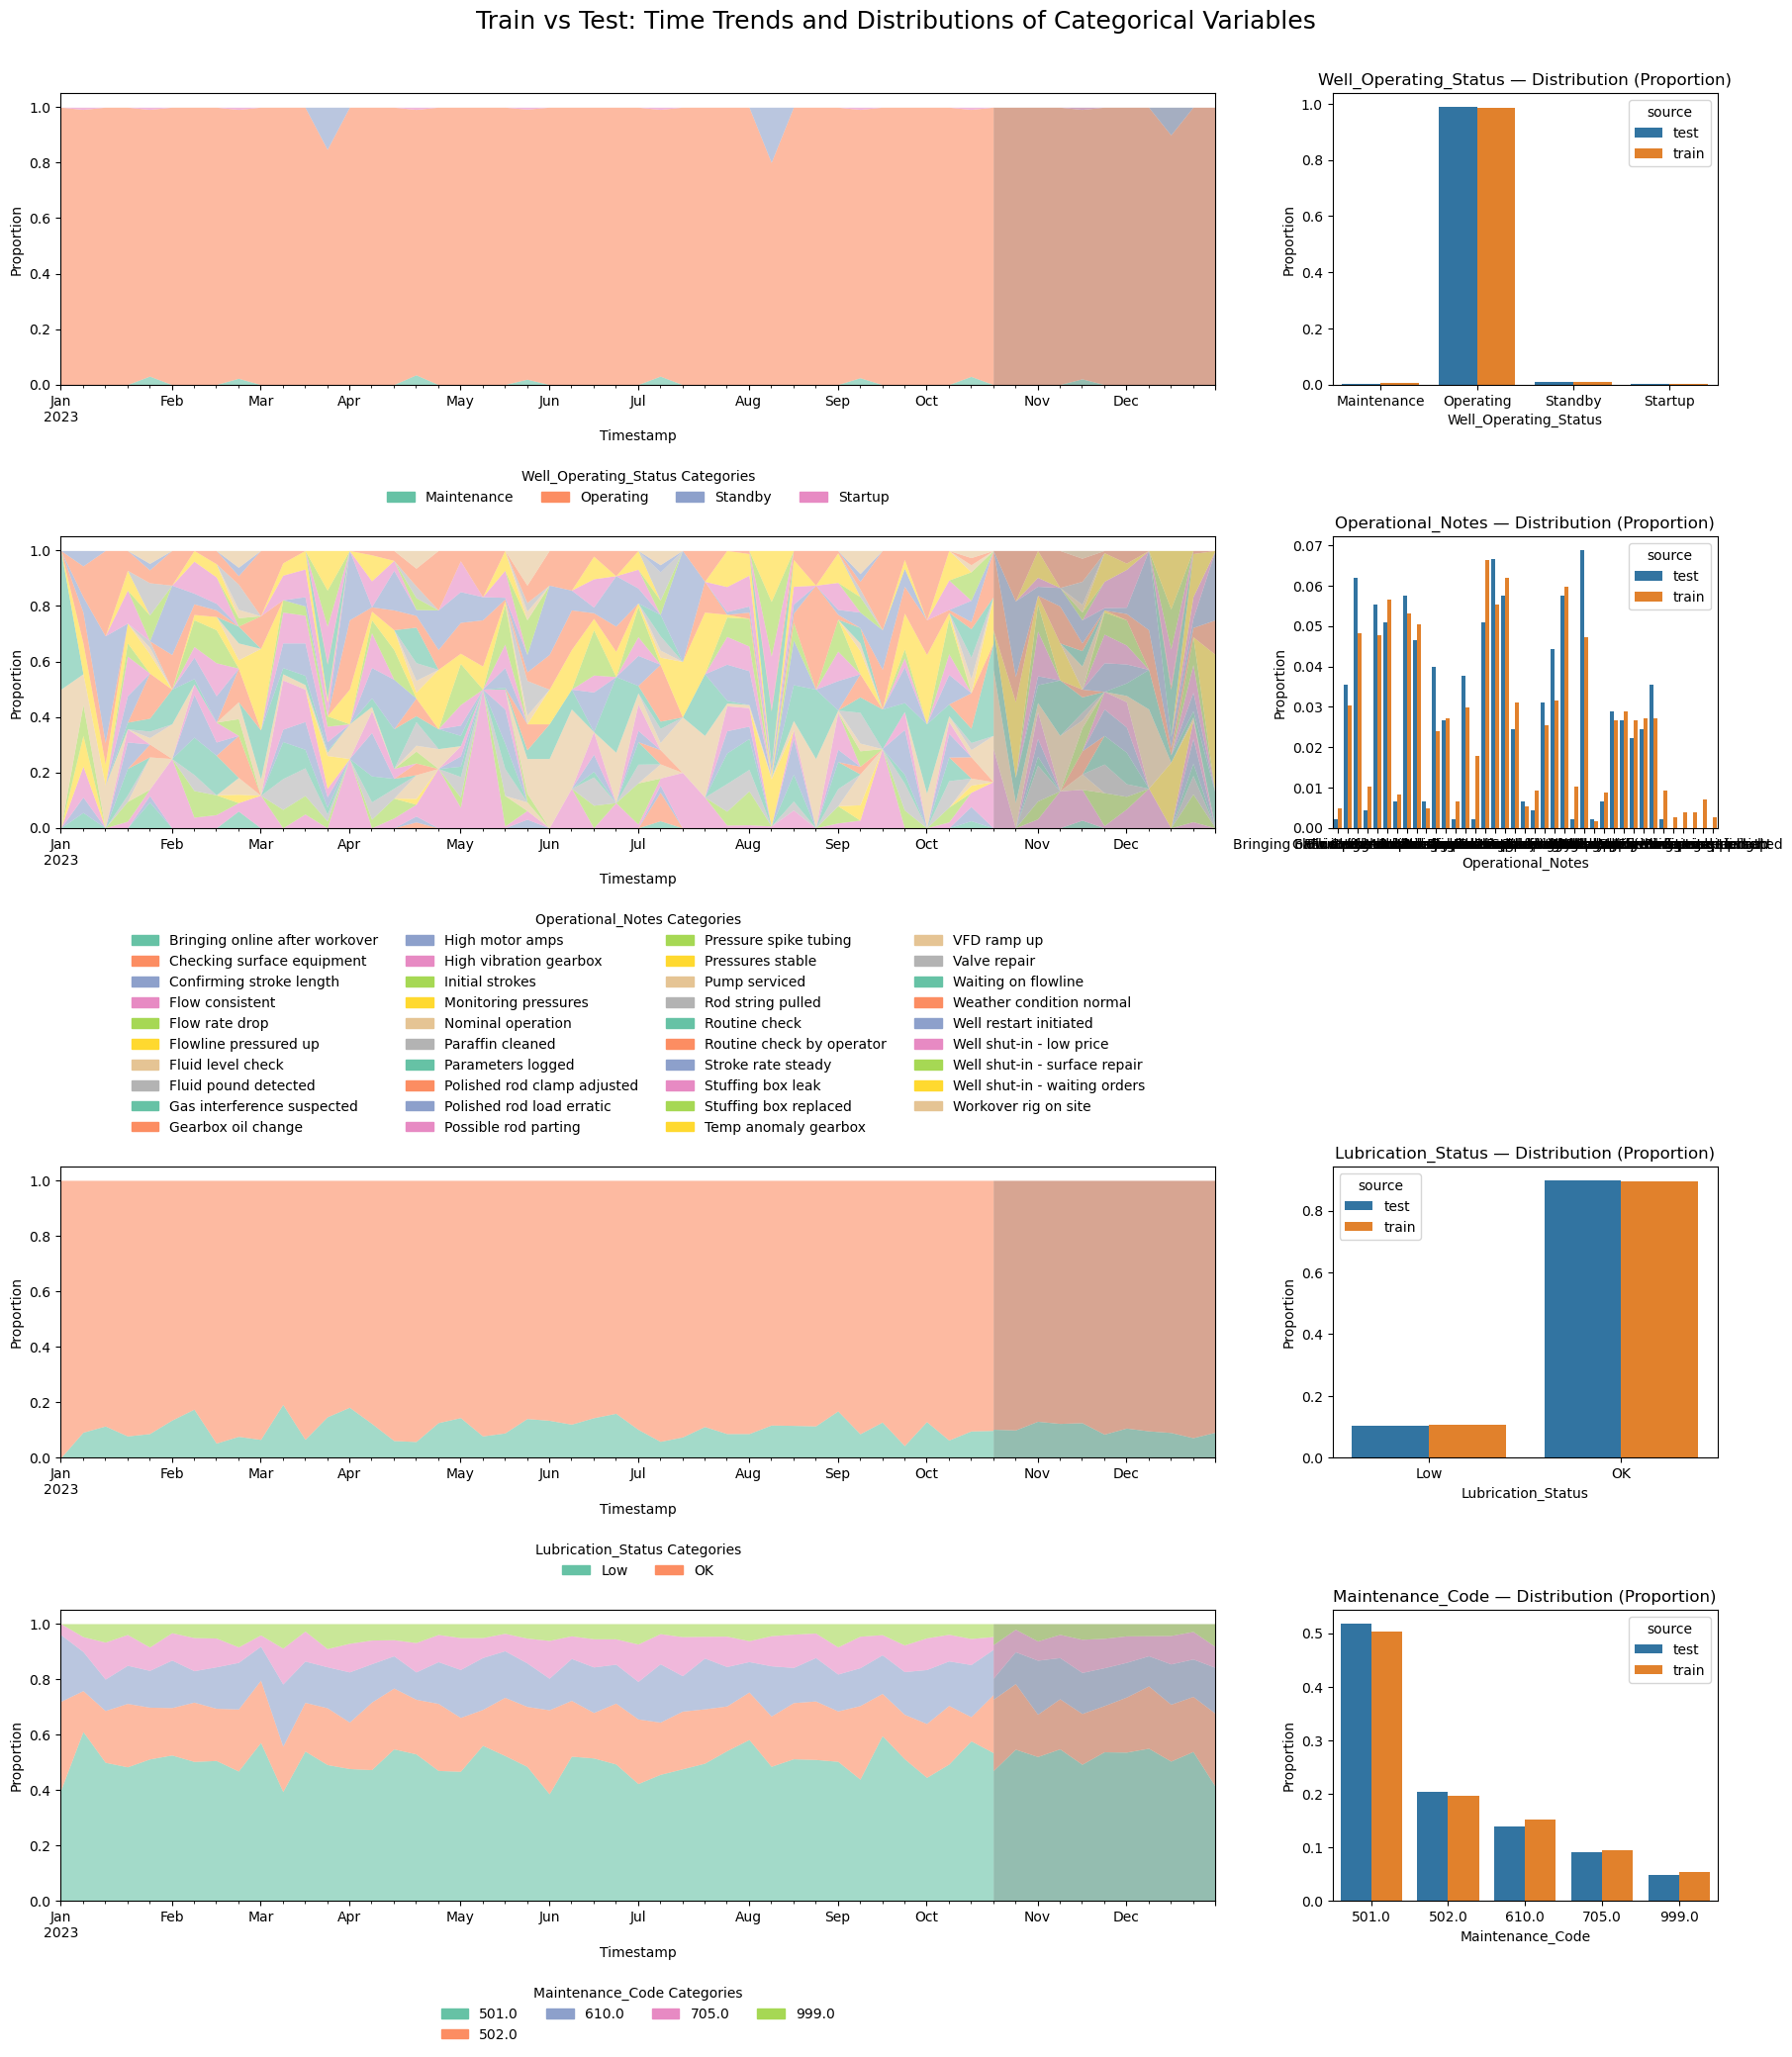

In [29]:
# Add source tag
nonnum_train['source'] = 'train'
nonnum_test['source'] = 'test'
combined_cat = pd.concat([nonnum_train, nonnum_test], axis=0).reset_index(drop=True)

# Timestamp range
full_timestamps = combined_cat['Timestamp'].drop_duplicates().sort_values()
min_time = full_timestamps.min()
max_time = full_timestamps.max()

# Categorical columns (excluding Timestamp/source)
cat_cols = [col for col in nonnum_train.columns if col not in ['Timestamp', 'source']]
n_cats = len(cat_cols)

# Create 2 subplots per categorical variable (train/test on left, distribution on right)
fig = plt.figure(figsize=(18, 5 * n_cats), constrained_layout=True)
gs = gridspec.GridSpec(n_cats, 2, width_ratios=[3, 1], figure=fig)


# Assign base colors per category value
category_color_maps = {}

for col in cat_cols:
    all_categories = sorted(combined_cat[col].dropna().unique())
    base_colors = sns.color_palette("Set2", len(all_categories))
    base_map = dict(zip(all_categories, base_colors))
    category_color_maps[col] = base_map

for i, col in enumerate(cat_cols):
    # Prepare proportion data
    freq = combined_cat.groupby([pd.Grouper(key='Timestamp', freq='W'), col, 'source']).size().reset_index(name='count')
    freq['total'] = freq.groupby(['Timestamp', 'source'])['count'].transform('sum')
    freq['proportion'] = freq['count'] / freq['total']

    # LEFT: Faceted stacked area plots (train and test) in one subplot area
    ax_area = fig.add_subplot(gs[i, 0])

    for source_value, color in zip(['train', 'test'], ['tab:blue', 'tab:orange']):
        subset = freq[freq['source'] == source_value]    
        pivoted = subset.pivot_table(index='Timestamp', columns=col, values='proportion', aggfunc='sum').fillna(0)
        
        # Use same base color per category, with adjusted brightness
        def adjust_color(base_color, brightness=1.0):
            r, g, b = base_color
            return (r * brightness, g * brightness, b * brightness)
        
        # Train = base color, Test = slightly darker
        brightness = 1.0 if source_value == 'train' else 0.75
        colors = [adjust_color(category_color_maps[col][cat], brightness) for cat in pivoted.columns]
        
        pivoted.plot.area(
            ax=ax_area,
            stacked=True,
            alpha=0.6,
            linewidth=0,
            color=colors,
            legend=False  
        )

    ax_area.set_xlim([min_time, max_time])
    ax_area.set_xlabel("Timestamp")
    ax_area.set_ylabel("Proportion")

    # Only add one legend for the categories (based on base_map)
    handles = []
    labels = []
    
    for category, color in category_color_maps[col].items():
        patch = plt.matplotlib.patches.Patch(color=color, label=category)
        handles.append(patch)
        labels.append(category)
    
    # Horizontal legend below the plot
    ax_area.legend(
        handles=handles,
        title=f"{col} Categories",
        loc='upper center',
        bbox_to_anchor=(0.5, -0.25),
        ncol=min(4, len(handles)),  # Adjust column count based on number of categories
        frameon=False)


    # RIGHT: Proportional barplot (train vs test)
    ax_bar = fig.add_subplot(gs[i, 1])
    dist = combined_cat.groupby(['source', col]).size().reset_index(name='count')
    dist['total'] = dist.groupby('source')['count'].transform('sum')
    dist['proportion'] = dist['count'] / dist['total']
    sns.barplot(data=dist, x=col, y='proportion', hue='source', ax=ax_bar)
    ax_bar.set_title(f"{col} — Distribution (Proportion)")
    ax_bar.set_xlabel(col)
    ax_bar.set_ylabel("Proportion")

fig.suptitle("Train vs Test: Time Trends and Distributions of Categorical Variables", fontsize=18, y=1.03)
plt.show()

Findings:

1. Training and test data seem to be from the same distribution and there seems no distribution shift.
2. Categorical values for Well_Operating_Status, Lubrication_Status, and Maintenance_Code are unbalanced, implying the major category indicates normal condition.

The plot below shows the changes of quantity over time for each variable.

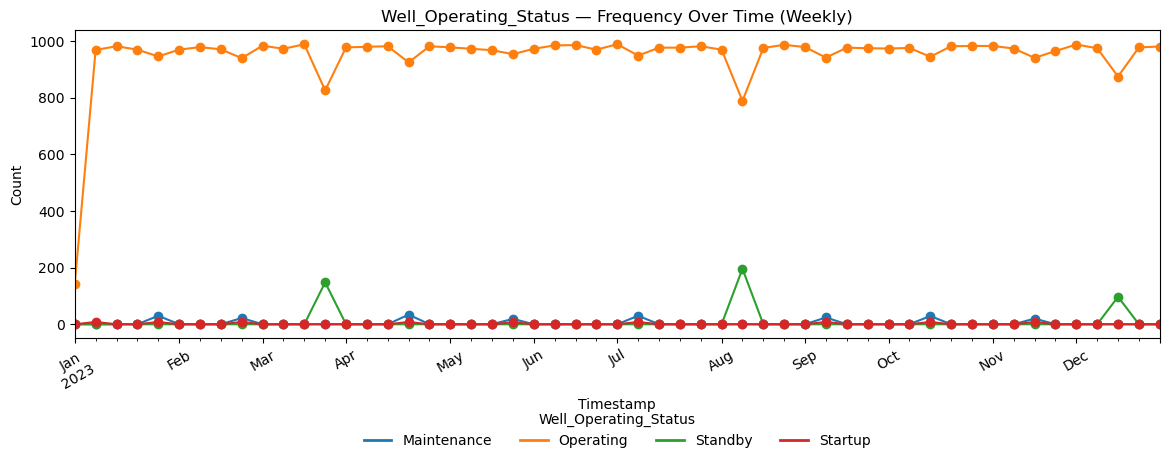

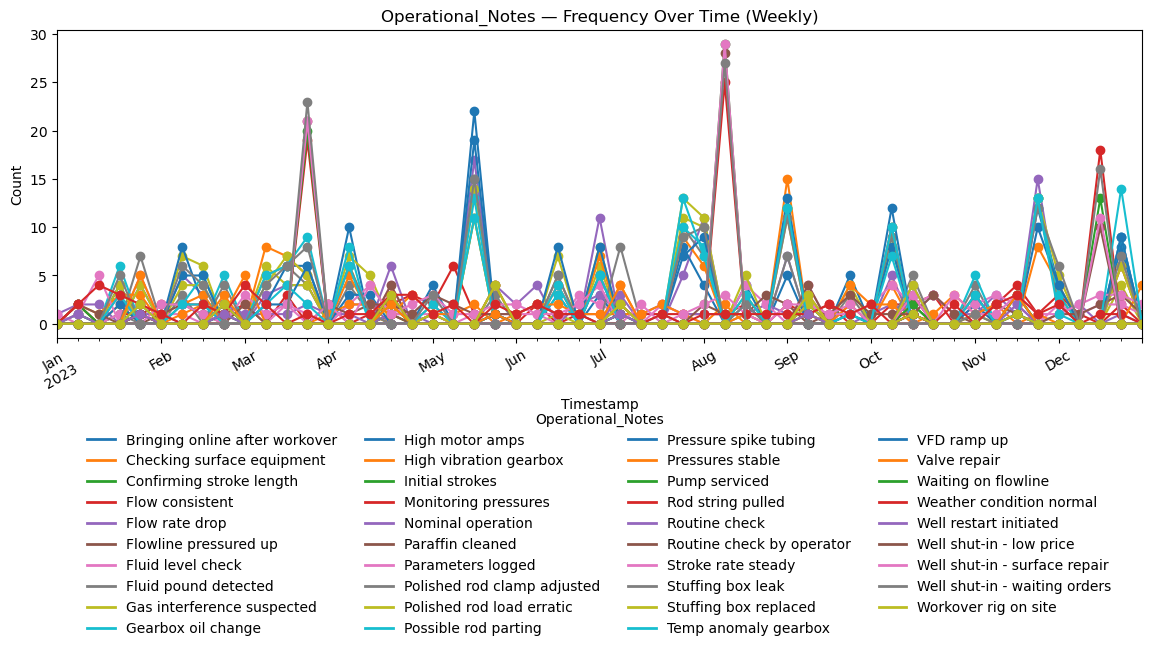

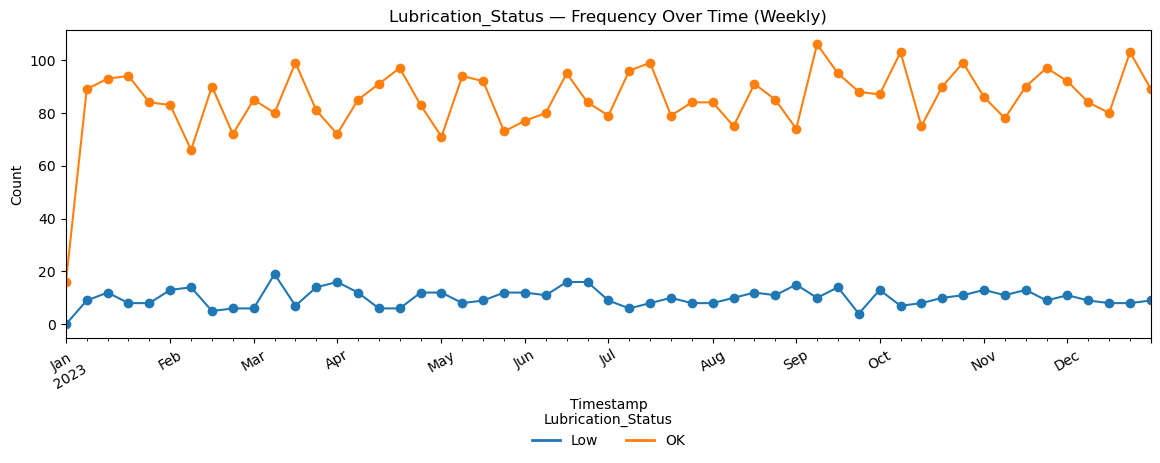

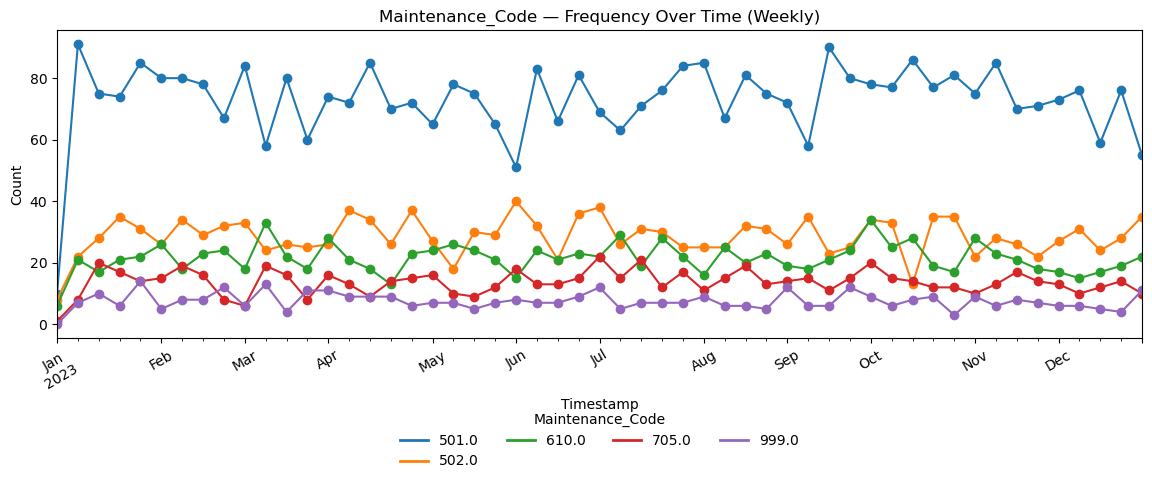

In [30]:
for col in cat_cols:
    plt.figure(figsize=(14, 4))
    
    # Group by week and category
    freq = combined_cat.groupby([pd.Grouper(key='Timestamp', freq='W'), col]).size().reset_index(name='count')

    # Pivot for plotting
    freq_pivot = freq.pivot(index='Timestamp', columns=col, values='count').fillna(0)

    # Plot without legend
    ax = plt.gca()
    freq_pivot.plot(ax=ax, marker='o', legend=False)

    # Title and axis formatting
    ax.set_title(f"{col} — Frequency Over Time (Weekly)")
    # ax.set_xlabel("Timestamp")
    ax.set_ylabel("Count")
    ax.set_xlim([min_time, max_time])
    ax.tick_params(axis='x', rotation=30)

    # Custom horizontal legend below the plot
    handles = [plt.Line2D([0], [0], color=ax.lines[i].get_color(), lw=2) for i in range(len(freq_pivot.columns))]
    labels = freq_pivot.columns.tolist()

    ax.legend(
        handles=handles,
        labels=labels,
        title=col,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.2),
        ncol=min(4, len(labels)),
        frameon=False
    )

    # plt.tight_layout(rect=[0.1, 0.1, 1, 1])
    plt.show()

It is found that there are some noticeiable peaks - in late Mar, mid May, early Aug (highest), ... - over time for Operational_Notes. Other variables looks stable in their frequencies.

Overall, there seem to be no differences of distributions of concern from categorical variables.  
Relationship between 1. Alerting signals (label), 2. Extreme values of numericals, 3. Frequency changes of categoricals could be analyzed.

# Univariate Analysis on the Label

In [31]:
# Distribution of Y 
print("Counts: \n", train['Monitoring_Alert'].value_counts())

Counts: 
 Monitoring_Alert
0    36912
1     3875
Name: count, dtype: int64


In [32]:
alert_counts = train['Monitoring_Alert'].value_counts(normalize=True).rename("Proportion")
alert_counts = alert_counts.reset_index().rename(columns={'index': 'Label'})

In [33]:
alert_counts

,Monitoring_Alert,Proportion
0,0,0.904994
1,1,0.095006


Note - unbalanced. 90% accuracy is the baseline.

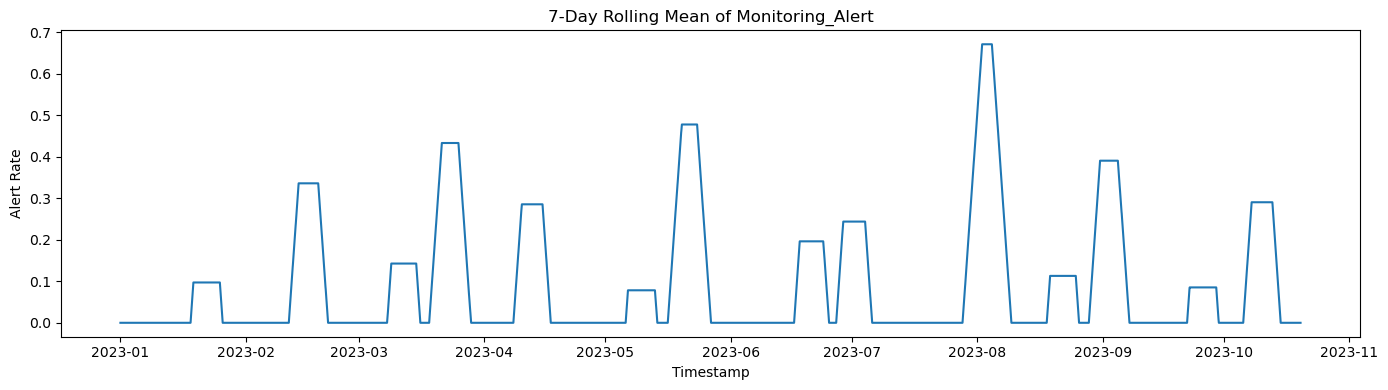

In [34]:
# Prep time-based fields
def add_time_features(df):
    df = df.copy()  # to avoid modifying in-place

    df['Hour'] = df['Timestamp'].dt.hour
    df['Weekday'] = df['Timestamp'].dt.dayofweek
    df['Date'] = df['Timestamp'].dt.floor('D')
    df['IsWeekend'] = (df['Weekday'] >= 5).astype(int)
    df['WeekOfMonth'] = (df['Timestamp'].dt.day - 1) // 7

    return df

train = add_time_features(train)
test = add_time_features(test)

# 3. Rolling 7-day average
train_roll = train.copy()
train_roll['Rolling_7d'] = train_roll['Monitoring_Alert'].rolling(window=144*7, min_periods=1).mean()
plt.figure(figsize=(14, 4))
plt.plot(train_roll['Timestamp'], train_roll['Rolling_7d'])
plt.title("7-Day Rolling Mean of Monitoring_Alert")
plt.ylabel("Alert Rate")
plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

Findings:  
1. There are some isolated spikes of 12 - 14 times and the highests in some months - Aug, mid May, late March. The spikes look alike to the Operational_Notes. The correlation should be investigated throughly as the causation might be the opposite of desired.
2. Seasonality doesn't seem to exist.

## Autocorrelation Study

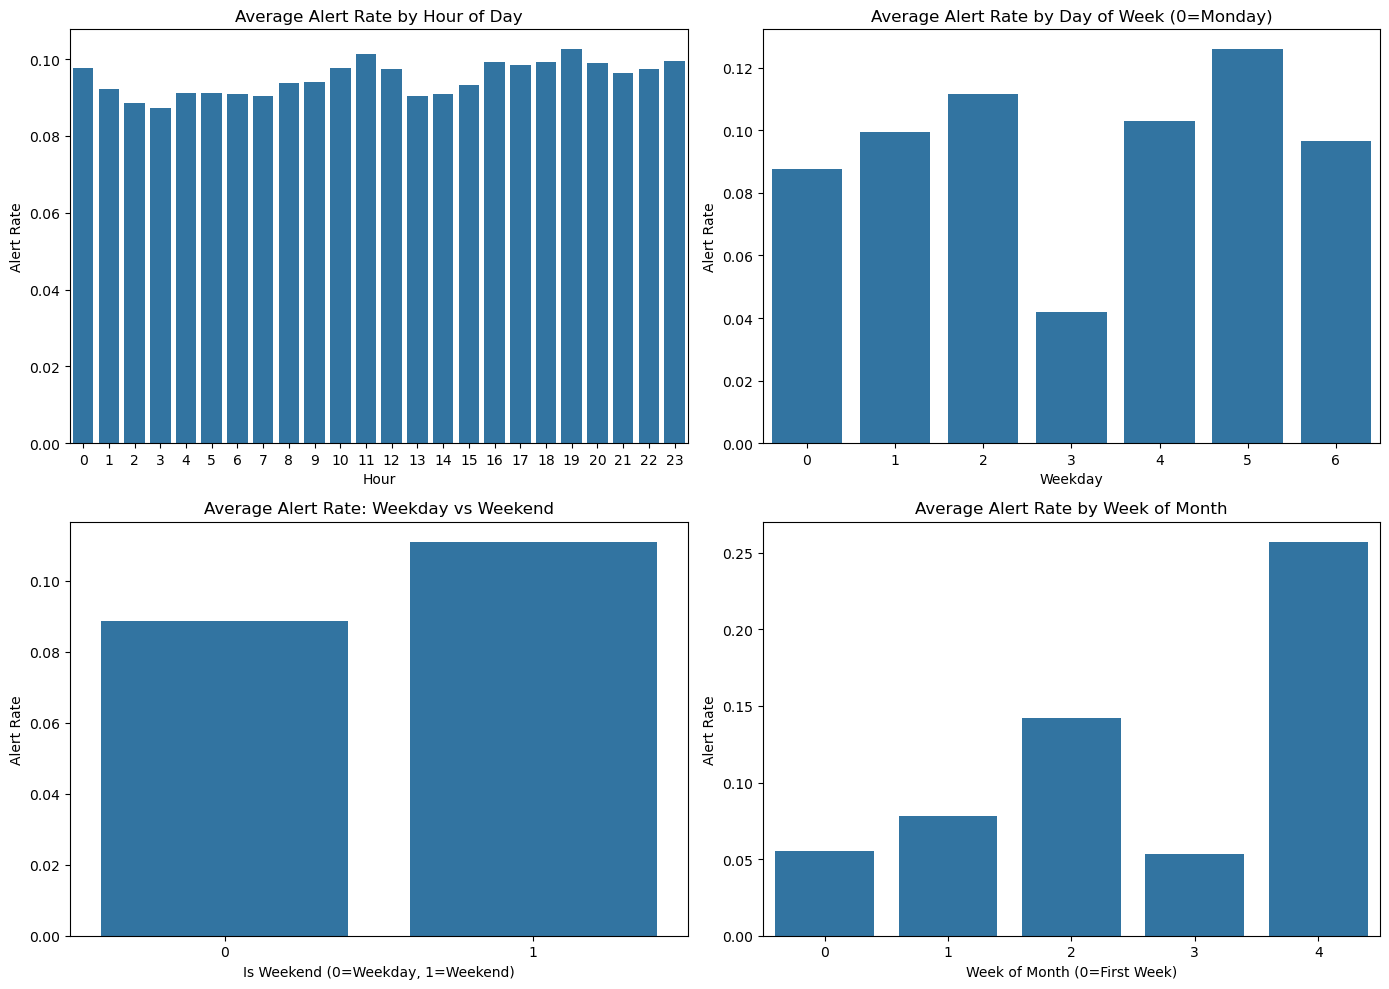

In [35]:
# Compute group statistics
hourly = train.groupby('Hour')['Monitoring_Alert'].mean()
weekday = train.groupby('Weekday')['Monitoring_Alert'].mean()
isweekend = train.groupby('IsWeekend')['Monitoring_Alert'].mean()
weekofmonth = train.groupby('WeekOfMonth')['Monitoring_Alert'].mean()

# Set up side-by-side plots in 3 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # flatten to 1D array for easier indexing

# Plot 1: Alert rate by hour of day
sns.barplot(x=hourly.index, y=hourly.values, ax=axes[0])
axes[0].set_title("Average Alert Rate by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Alert Rate")

# Plot 2: Alert rate by weekday
sns.barplot(x=weekday.index, y=weekday.values, ax=axes[1])
axes[1].set_title("Average Alert Rate by Day of Week (0=Monday)")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Alert Rate")

# Plot 3: Alert rate by IsWeekend
sns.barplot(x=isweekend.index, y=isweekend.values, ax=axes[2])
axes[2].set_title("Average Alert Rate: Weekday vs Weekend")
axes[2].set_xlabel("Is Weekend (0=Weekday, 1=Weekend)")
axes[2].set_ylabel("Alert Rate")

# Plot 4: Alert rate by Week of Month
sns.barplot(x=weekofmonth.index, y=weekofmonth.values, ax=axes[3])
axes[3].set_title("Average Alert Rate by Week of Month")
axes[3].set_xlabel("Week of Month (0=First Week)")
axes[3].set_ylabel("Alert Rate")


# Final layout adjustment
plt.tight_layout()
plt.show()

All of the time features seem correlated with the label. 

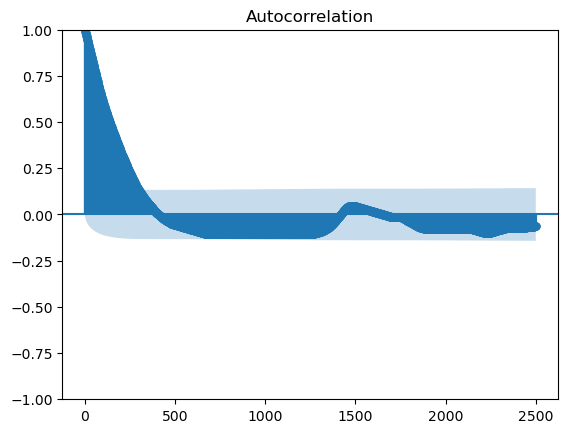

In [36]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(train['Monitoring_Alert'], lags=2500)
plt.show()

Strong autocorrelation from short term lags. Lag 1 to lag 50 could be considered although not meaningful in the sense of domain knowledge.

# Missing value Analysis
The missingness itself can be an indicator or information of obtainable.

Type of missing values  
- MCAR (Missing Completely At Random): The missingness is entirely random and unrelated to any observed or unobserved data.
- MAR (Missing At Random): The missingness depends only on observed data, not on the missing values themselves.
- MNAR (Missing Not At Random): The missingness depends on the unobserved data — the values that are missing influence the likelihood of being missing.

Searching on the types of missing is helpful for imputing them.

Next steps:
1. Column-wise % missing: Helps you decide imputation vs. removal.
2. Row-wise % missing: Helps detect bad rows (e.g., mostly missing).
3. Compare train vs. test: Checks for data leakage or distribution shift.


### Column-wise missing comparison

In [37]:
# === 6. Missing Value Analysis ===
def missing_percent(x):
    return x.isna().sum() / len(x) * 100

mss_cl_tr = train.apply(missing_percent)
mss_cl_tst = test.apply(missing_percent)
mss_cl_tr_wo_y = mss_cl_tr.drop(labels='Monitoring_Alert', errors='ignore')

missing_summary = pd.concat([mss_cl_tr, mss_cl_tst], axis=1)
missing_summary.rename(columns={0:'Training', 1:'Test'},inplace = True)

In [38]:
missing_summary.sort_values(by = 'Training', ascending= False)

,Training,Test
Operational_Notes,95.486307,95.577131
Lubrication_Status,90.170888,89.810729
Maintenance_Code,84.811337,85.760518
Liquid_Flow_Rate_m3d,3.008311,2.745906
Tubing_Pressure_psi,2.434599,2.579190
VFD_Speed_pct,2.003089,1.843680
Gearbox_Temperature_C,1.976120,1.951554
Surface_Temperature_C,1.458798,1.549475
Acoustic_Sensor_Env_dB,1.005222,0.902226
Timestamp,0.000000,0.000000


Training and test data seems to have similar missing percentages over each column

In [39]:
# Collect the missing variables only, 
mss_smmr_df = missing_summary.reset_index()
mss_cols = mss_smmr_df.loc[(mss_smmr_df['Training'] > 0) & (mss_smmr_df['Test'] > 0), 'index']
mss_cols

2          Operational_Notes
3     Acoustic_Sensor_Env_dB
7      Gearbox_Temperature_C
10      Liquid_Flow_Rate_m3d
11        Lubrication_Status
12          Maintenance_Code
17     Surface_Temperature_C
18       Tubing_Pressure_psi
19             VFD_Speed_pct
Name: index, dtype: object

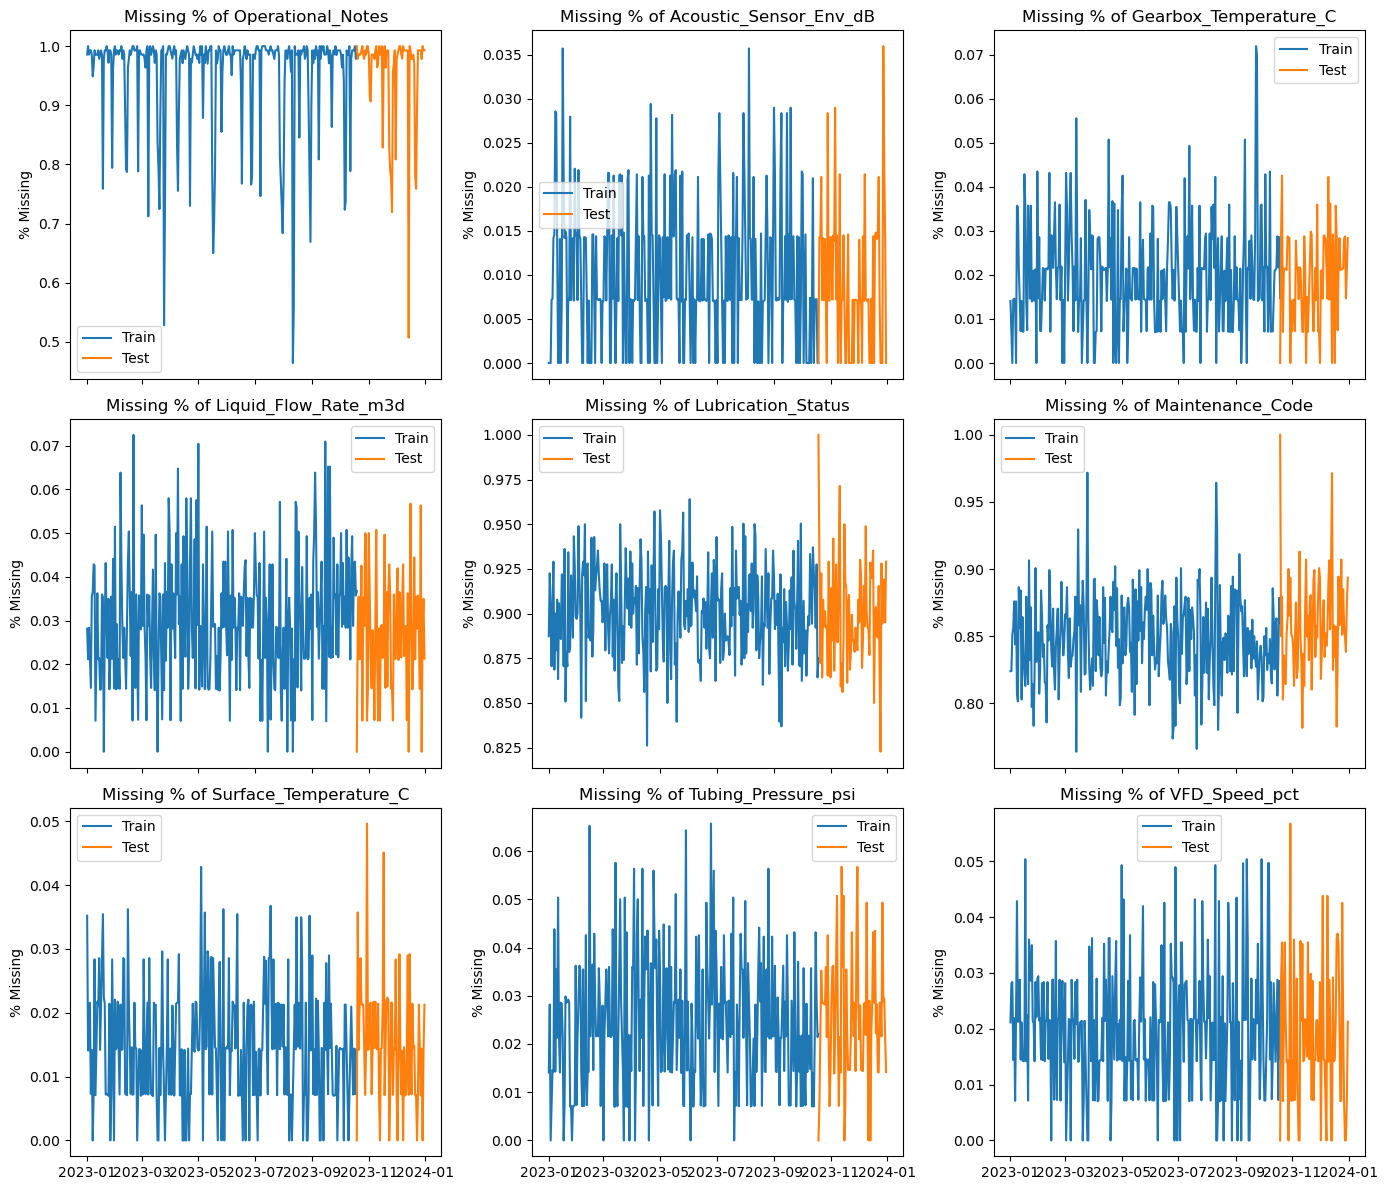

In [40]:
import math

# Align dates
train['Date'] = train['Timestamp'].dt.date
test['Date'] = test['Timestamp'].dt.date

# Define grid size based on number of columns
num_cols = len(mss_cols)
n_cols = 3  # Number of plots per row
n_rows = math.ceil(num_cols / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=True)
axes = axes.flatten()  # Make it easier to iterate

for i, col in enumerate(mss_cols):
    daily_missing_train = train.groupby('Date')[col].apply(lambda x: x.isna().mean())
    daily_missing_test = test.groupby('Date')[col].apply(lambda x: x.isna().mean())

    axes[i].plot(daily_missing_train, label='Train')
    axes[i].plot(daily_missing_test, label='Test')
    axes[i].set_title(f'Missing % of {col}')
    axes[i].set_ylabel('% Missing')
    axes[i].legend()

# Remove unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The plot above shows the quantity of missing values over time are alike between training and test data set.

The distribution of missing values from training and test data sets seem to be similar to each other. The test error estimation from training data set could be valid.

Note: Categorical variables are missing huge


## Row-wise Missing Comparison

In [41]:
mss_r_tr = train.isna().mean(axis=1) * 100
mss_r_tst = test.isna().mean(axis=1) * 100

In [42]:
mss_r_tst_smmr = mss_r_tst.value_counts().reset_index()
mss_r_tr_smmr = mss_r_tr.value_counts().reset_index()

In [43]:
mss_r_tst_smmr.columns = ['test_missing_perc', 'test_counts']
mss_r_tr_smmr.columns = ['train_missing_perc', 'train_counts']

In [44]:
mss_r_tst_smmr['test_density'] = mss_r_tst_smmr['test_counts']/len(mss_r_tst) * 100
mss_r_tr_smmr['train_density'] = mss_r_tr_smmr['train_counts']/len(mss_r_tr) * 100

In [45]:
missing_summary_row = pd.concat([mss_r_tst_smmr, mss_r_tr_smmr], axis=1)

In [46]:
missing_summary_row['test_missing_perc'] = missing_summary_row['test_missing_perc']
missing_summary_row['test_missing_perc'] = missing_summary_row['train_missing_perc']

In [47]:
missing_summary_row[['test_missing_perc', 'test_density', 'train_missing_perc', 'train_density']].round(2)

,test_missing_perc,test_density,train_missing_perc,train_density
0,11.54,67.76,11.54,66.88
1,7.69,21.84,7.69,22.28
2,15.38,8.46,15.38,8.79
3,3.85,1.92,3.85,1.99
4,0.00,0.02,0.00,0.06


Systematic missingness - there are not many missing cases in row-wise (missing columns are always missing regardless of train/test), and they can be categorized by 5 missing percentage for rows, and the distribution of missing cases is somewhat similar.  
**It looks like when a field is missing, then other fields are likely to be missing their values.** 

## Visualization: Column and Row Wise Missing Trends

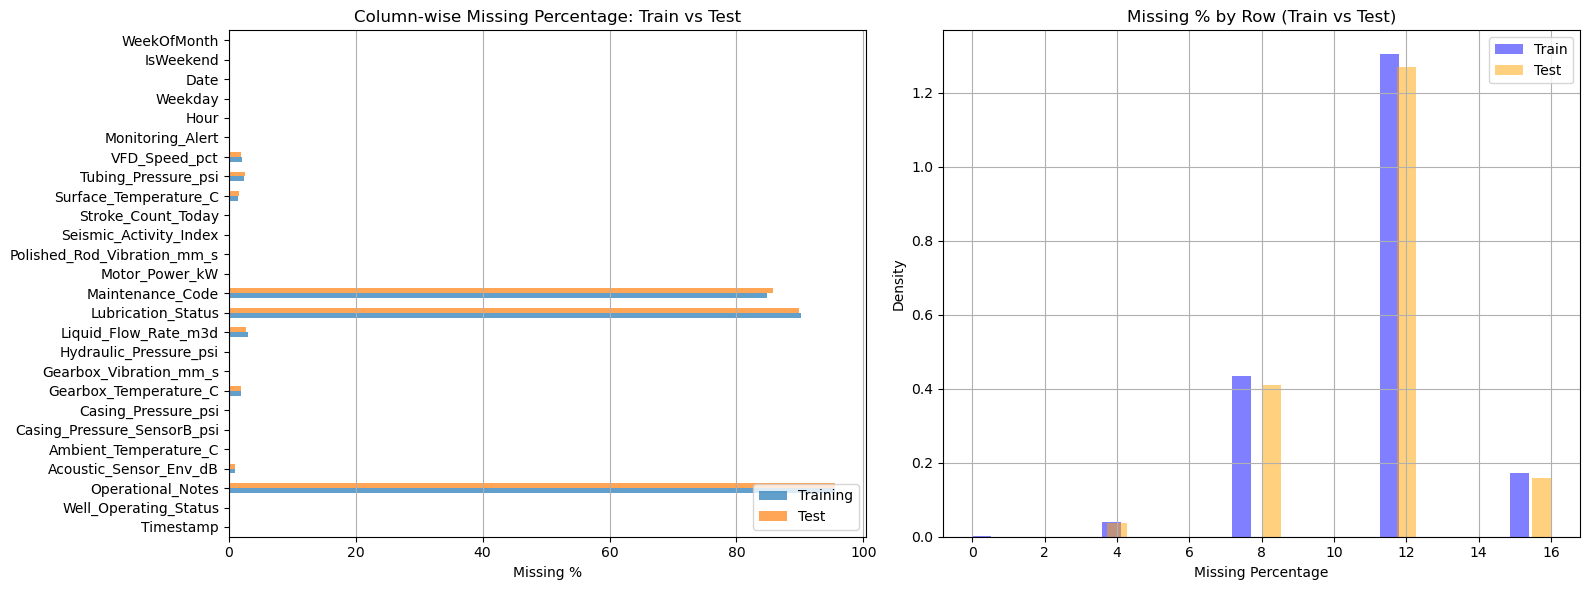

In [48]:
# Set up side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Column-wise Missing Percentage ---
missing_summary.plot(kind='barh', alpha=0.7, ax=axes[0])
axes[0].set_xlabel("Missing %")
axes[0].set_title("Column-wise Missing Percentage: Train vs Test")
axes[0].legend(loc='lower right')
axes[0].grid(axis='x')

# --- Plot 2: Row-wise Missing Percentage Histogram ---
axes[1].hist(mss_r_tr, bins=30, density=True, alpha=0.5, label='Train', color='blue')
axes[1].hist(mss_r_tst, bins=30, density=True, alpha=0.5, label='Test', color='orange')
axes[1].set_title('Missing % by Row (Train vs Test)')
axes[1].set_xlabel('Missing Percentage')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True)

# Final layout adjustment
plt.tight_layout()
plt.show()

Training and test data is likely to have identical distributions of missing values.

## Imputation 


### 1. Impute numerical variables with relatively low missing percentages
For the sake of modelling, forward filling and median filling are used to prevent data leakage.

In [49]:
def impute_time_series_features(df, columns):
    """
    Imputes missing values in a time series DataFrame:
    - First applies forward fill (`ffill`)
    - Then fills any remaining NaNs (typically at the beginning) with the median.

    Parameters:
        df (pd.DataFrame): Input DataFrame with time series columns.
        columns (list): List of column names to apply imputation to.

    Returns:
        pd.DataFrame: DataFrame with specified columns imputed.
    """
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = df[col].ffill()  # forward fill
            df[col] = df[col].fillna(df[col].median())  # remaining NaNs
    return df

In [50]:
col_impute = missing_summary.query('Training < 5 and Test < 5 and Training > 0 and Test > 0').index

In [51]:
col_impute

Index(['Acoustic_Sensor_Env_dB', 'Gearbox_Temperature_C',
       'Liquid_Flow_Rate_m3d', 'Surface_Temperature_C', 'Tubing_Pressure_psi',
       'VFD_Speed_pct'],
      dtype='object')

In [52]:
df = pd.concat([train, test], axis=0)
df_imp = impute_time_series_features(df, col_impute)

### 2. Impute categorical variables with heavily missing percentages

In [53]:
# Check if missing overlaps
missing_cols = ['Operational_Notes', 'Lubrication_Status', 'Maintenance_Code']
df[missing_cols].isna().sum(axis=1).value_counts()

3    37193
2    12624
1     1138
0       29
Name: count, dtype: int64

It is likey that the heavy missing categorical variables are due to the fact that the machine of interest is operating normal, and no manual note, lubrication, or maintanence were required. The trend of missing in row-wise and above table also support the argument. Hence, missing rows are filled with text value such as 'no_comment'.

In [54]:
df_imp['Operational_Notes'] = df_imp['Operational_Notes'].fillna('no_comment')

df_imp['Lubrication_Status'] = df_imp['Lubrication_Status'].cat.add_categories('Unknown')
df_imp['Lubrication_Status'] = df_imp['Lubrication_Status'].fillna('Unknown')

df_imp['Maintenance_Code'] = df_imp['Maintenance_Code'].cat.add_categories('NoCode')
df_imp['Maintenance_Code'] = df_imp['Maintenance_Code'].fillna('NoCode').astype(str)

In [55]:
df_imp.sample(5)

,Timestamp,Well_Operating_Status,Operational_Notes,Acoustic_Sensor_Env_dB,Ambient_Temperature_C,Casing_Pressure_SensorB_psi,Casing_Pressure_psi,Gearbox_Temperature_C,Gearbox_Vibration_mm_s,Hydraulic_Pressure_psi,Liquid_Flow_Rate_m3d,Lubrication_Status,Maintenance_Code,Motor_Power_kW,Polished_Rod_Vibration_mm_s,Seismic_Activity_Index,Stroke_Count_Today,Surface_Temperature_C,Tubing_Pressure_psi,VFD_Speed_pct,Monitoring_Alert,Hour,Weekday,Date,IsWeekend,WeekOfMonth
866,2023-10-26 02:40:00,Operating,no_comment,41.653779,30.015963,54.899023,54.149854,78.932327,0.549122,26.473180,94.039303,Unknown,NoCode,59.583068,0.929809,5.253661,64,61.808782,176.100818,68.891755,NaN,2,3,2023-10-26,0,3
8824,2023-12-22 05:20:00,Operating,High motor amps,38.140302,37.144762,51.648110,51.210728,85.723065,0.580886,25.496472,89.903919,Unknown,NoCode,63.049599,0.765183,5.495600,128,68.086249,160.608780,67.700125,NaN,5,4,2023-12-22,0,3
29978,2023-08-03 14:50:00,Operating,no_comment,49.268575,7.222956,53.568900,51.925737,74.146090,0.504025,30.358888,98.639900,Unknown,NoCode,54.835837,0.759747,11.721329,356,58.412541,178.249272,65.934573,0.0,14,3,2023-08-03,0,0
28247,2023-07-22 05:30:00,Operating,no_comment,48.567992,3.434479,54.009942,52.328576,75.895753,0.487944,29.081668,95.847299,Unknown,NoCode,55.865309,0.868099,5.980360,132,57.748780,183.497001,81.040506,0.0,5,5,2023-07-22,1,3
28157,2023-07-21 13:50:00,Operating,no_comment,46.270752,2.803563,51.862810,50.144817,73.408273,0.432819,30.540879,96.532536,Unknown,NoCode,55.493348,0.943835,6.416614,332,59.043149,181.890042,75.728836,0.0,13,4,2023-07-21,0,2


In [56]:
# df_imp.to_csv('./df_imp.csv', index=False) # Saving df_imp for part 2

In [57]:
# Ensure all categorical features are of type 'category'
categorical_cols = [
    'Operational_Notes',
    'Well_Operating_Status',
    'Lubrication_Status',
    'Maintenance_Code'
]
for col in categorical_cols:
    if col in df_imp.columns:
        df_imp[col] = pd.Categorical(df_imp[col])

In [58]:
df_imp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50984 entries, 0 to 10196
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Timestamp                    50984 non-null  datetime64[ns]
 1   Well_Operating_Status        50984 non-null  category      
 2   Operational_Notes            50984 non-null  category      
 3   Acoustic_Sensor_Env_dB       50984 non-null  float64       
 4   Ambient_Temperature_C        50984 non-null  float64       
 5   Casing_Pressure_SensorB_psi  50984 non-null  float64       
 6   Casing_Pressure_psi          50984 non-null  float64       
 7   Gearbox_Temperature_C        50984 non-null  float64       
 8   Gearbox_Vibration_mm_s       50984 non-null  float64       
 9   Hydraulic_Pressure_psi       50984 non-null  float64       
 10  Liquid_Flow_Rate_m3d         50984 non-null  float64       
 11  Lubrication_Status           50984 non-null  c

No missing found from imputed data set. 

# Bivariate Analysis

## Feature Engineering and Variable Selection

### Collect Feature Candidates
Now only focusing on training data set to find relevant engineered features for predicting label.

Split train (70%), validation (20%), test (10%) data for preventing overfitting, opmization bias, and maximizing model performance.

In [59]:
# Split index
n = len(train)
split_point = int(n * 0.7)  
split_point_ = int(n * 0.9)  

# Split data
train_imp = df_imp.iloc[train.index]
test_imp = df_imp.iloc[test.index]
sub_train = train_imp.iloc[:split_point]
val = train_imp.iloc[split_point:split_point_]
hold_out = train_imp.iloc[split_point_:]

From the ACF plots earlier, short term lags are found to be meaningful. Basic feature engineering with lag and rolling were tested below.
Spearman corelation was measured for numerical variables with the label as non-linear relationships are more likely. Mutual information was mesured for categorical variables with the label.

#### Post Submission Adjustment 2
mutual information function added arguments

In [140]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif

def generate_combined_features(df, y_col, num_cols, cat_cols, 
                               lags=[1, 2, 3, 6, 12, 36, 72, 144, 288], 
                               roll_windows=[6, 12, 36, 72, 144, 288], 
                               top_n=10,
                               corr_method='spearman'):
    """
    Generate lagged and rolling features for numeric columns,
    and lag/transition features for categorical columns.
    Select top_n features from each type based on relevance to target y_col.

    Parameters:
        df (pd.DataFrame): Input data.
        y_col (str): Target column.
        num_cols (list): Numerical feature names.
        cat_cols (list): Categorical feature names.
        lags (list): Time lags to generate.
        roll_windows (list): Rolling window sizes.
        top_n (int): Number of top features to keep per type.
        corr_method (str): Correlation method for numeric ('pearson' or 'spearman').

    Returns:
        final_df (pd.DataFrame): Selected features.
        scores_dict (dict): Feature scores {'numerical': Series, 'categorical': Series}.
    """
    df = df.copy()
    num_feature_frames = []
    cat_feature_frames = []
    corr_scores = {}

    # --- NUMERICAL FEATURES: Lag + Rolling ---
    for col in num_cols:
        for lag in lags:
            lagged = df[col].shift(lag)
            lag_name = f'{col}_lag_{lag}'
            num_feature_frames.append(lagged.rename(lag_name))
            corr_scores[lag_name] = lagged.corr(df[y_col], method=corr_method)

        for w in roll_windows:
            roll_mean = df[col].shift(1).rolling(window=w).mean()
            roll_std = df[col].shift(1).rolling(window=w).std()
            mean_name = f'{col}_rollmean_{w}'
            std_name = f'{col}_rollstd_{w}'
            num_feature_frames.append(roll_mean.rename(mean_name))
            num_feature_frames.append(roll_std.rename(std_name))
            corr_scores[mean_name] = roll_mean.corr(df[y_col], method=corr_method)
            corr_scores[std_name] = roll_std.corr(df[y_col], method=corr_method)

    # --- CATEGORICAL FEATURES: Lag + Transition ---
    for col in cat_cols:
        current = df[col].astype(str)
        for lag in lags:
            lagged = df[col].shift(lag).astype(str)
            lag_col_name = f'{col}_lag_{lag}'
            trans_col_name = f'{col}_transition_lag{lag}'

            cat_feature_frames.append(lagged.rename(lag_col_name))
            transition = (lagged + "_to_" + current).astype("category")
            cat_feature_frames.append(transition.rename(trans_col_name))

    # --- COMBINE ALL FEATURES ---
    all_features_df = pd.concat(num_feature_frames + cat_feature_frames, axis=1)

    # --- SELECT NUMERICAL FEATURES BY CORRELATION ---
    corr_series = pd.Series(corr_scores).dropna()
    top_num_features = corr_series.abs().sort_values(ascending=False).head(top_n).index.tolist()

    # --- SELECT CATEGORICAL FEATURES BY MUTUAL INFORMATION ---
    if cat_feature_frames:
        cat_df = pd.concat(cat_feature_frames, axis=1).astype("category")
        # Fast encoding for mutual info: use ordinal codes
        cat_df_encoded = cat_df.apply(lambda x: x.cat.codes)
        # Fill missing values to avoid errors
        cat_df_encoded = cat_df_encoded.fillna(-1)
        # Compute mutual information
        mi_scores = mutual_ainfo_classif(cat_df_encoded, df[y_col], discrete_features=True, random_state=42)
        mi_series = pd.Series(mi_scores, index=cat_df.columns).sort_values(ascending=False)
        top_cat_features = mi_series.head(top_n).index.tolist()
    else:
        mi_series = pd.Series(dtype=float)
        top_cat_features = []

    # --- FINAL FEATURE SELECTION ---
    selected_cols = top_num_features + top_cat_features
    final_df = all_features_df[selected_cols]

    # Return selected features and scoring metadata
    return final_df, {'numerical': corr_series[top_num_features], 'categorical': mi_series[top_cat_features]}

In [143]:
selected_df, corr_mi_series = generate_combined_features(
    df=sub_train,
    y_col='Monitoring_Alert',
    num_cols=['Acoustic_Sensor_Env_dB', 'Ambient_Temperature_C',
       'Casing_Pressure_SensorB_psi', 'Casing_Pressure_psi',
       'Gearbox_Temperature_C', 'Gearbox_Vibration_mm_s',
       'Hydraulic_Pressure_psi', 'Liquid_Flow_Rate_m3d', 'Motor_Power_kW',
       'Polished_Rod_Vibration_mm_s', 'Seismic_Activity_Index',
       'Stroke_Count_Today', 'Surface_Temperature_C', 'Tubing_Pressure_psi',
       'VFD_Speed_pct'],
    cat_cols=['Well_Operating_Status', 'Operational_Notes',
       'Lubrication_Status', 'Maintenance_Code'],
    lags=[1, 2, 3, 6, 12, 36, 72, 144, 288, 432],
    roll_windows=[6, 12, 36, 72, 144, 288, 432],
    top_n=50
)

In [144]:
corr_mi_series['numerical']

Motor_Power_kW_rollmean_12                  0.320288
Motor_Power_kW_rollmean_6                   0.318028
Surface_Temperature_C_rollmean_6            0.313757
Surface_Temperature_C_rollmean_12           0.310808
Motor_Power_kW_rollmean_36                  0.305950
Surface_Temperature_C_lag_1                 0.295010
Surface_Temperature_C_lag_2                 0.292757
Surface_Temperature_C_lag_3                 0.291150
Surface_Temperature_C_rollmean_36           0.290402
Polished_Rod_Vibration_mm_s_rollmean_36     0.286890
Surface_Temperature_C_lag_6                 0.285309
Motor_Power_kW_rollmean_72                  0.282815
Polished_Rod_Vibration_mm_s_rollstd_144     0.277387
Motor_Power_kW_lag_1                        0.275148
Motor_Power_kW_lag_2                        0.273335
Surface_Temperature_C_lag_12                0.273296
Polished_Rod_Vibration_mm_s_rollmean_12     0.273088
Motor_Power_kW_lag_3                        0.271694
Motor_Power_kW_lag_6                        0.

In [145]:
corr_mi_series['categorical']

Operational_Notes_transition_lag2          0.101757
Operational_Notes_transition_lag3          0.101680
Operational_Notes_transition_lag1          0.100128
Operational_Notes_transition_lag6          0.099573
Operational_Notes_transition_lag12         0.097357
Operational_Notes_transition_lag36         0.088502
Operational_Notes_transition_lag72         0.079673
Operational_Notes_transition_lag144        0.067776
Operational_Notes_transition_lag288        0.059634
Operational_Notes_transition_lag432        0.059307
Operational_Notes_lag_1                    0.056263
Operational_Notes_lag_2                    0.055651
Operational_Notes_lag_3                    0.054649
Operational_Notes_lag_6                    0.052732
Operational_Notes_lag_12                   0.049668
Operational_Notes_lag_36                   0.038863
Operational_Notes_lag_72                   0.027433
Operational_Notes_lag_144                  0.014641
Operational_Notes_lag_288                  0.003424
Well_Operati

### Subset of Features with High Correlation Values 

In [146]:
import re

def filter_and_deduplicate_features(score_series, threshold=0.2, is_mutual_info=False):
    """
    Filters and deduplicates features based on either correlation or mutual information scores.
    
    Parameters:
        score_series (pd.Series): Feature importance scores (feature name as index)
        threshold (float): Minimum score to keep
        is_mutual_info (bool): If True, input is mutual information (non-negative). 
                               If False, input is correlation (may be negative).
    
    Returns:
        pd.Series: Filtered and deduplicated scores
    """
    # Step 1: Filter by threshold
    if is_mutual_info:
        filtered = score_series[score_series >= threshold]
    else:
        filtered = score_series[score_series.abs() >= threshold]

    if filtered.empty:
        return pd.Series(dtype=score_series.dtype)  # empty result

    # Step 2: Extract base column name using regex
    base_names = filtered.index.to_series().apply(lambda x: re.split(r'_lag_|_rollmean_|_rollstd_|_transition_', x)[0])
    filtered_df = pd.DataFrame({
        'feature': filtered.index,
        'score': filtered.values,
        'base': base_names.values
    })

    # Step 3: Keep best feature per base column
    filtered_df['sort_score'] = filtered_df['score'].abs() if not is_mutual_info else filtered_df['score']
    top_per_base = (
        filtered_df.sort_values('sort_score', ascending=False)
        .groupby('base')
        .first()
        .sort_values('sort_score', ascending=False)
    )

    # Return as Series
    return top_per_base.set_index('feature')['score']

In [147]:
final_corrs = filter_and_deduplicate_features(corr_mi_series['numerical'], threshold=0.05)
print(final_corrs)

# To get final feature names:
cor_features = final_corrs.index.tolist()

feature
Motor_Power_kW_rollmean_12                 0.320288
Surface_Temperature_C_rollmean_6           0.313757
Polished_Rod_Vibration_mm_s_rollmean_36    0.286890
Tubing_Pressure_psi_rollmean_6            -0.235466
Gearbox_Temperature_C_rollmean_12          0.220945
Casing_Pressure_psi_rollstd_432           -0.220807
Gearbox_Vibration_mm_s_rollmean_36         0.194875
Name: score, dtype: float64


In [150]:
final_corrs = filter_and_deduplicate_features(corr_mi_series['categorical'], threshold=0.001, is_mutual_info=True)
print(final_corrs)

# To get final feature names:
mi_features = final_corrs.index.tolist()

feature
Operational_Notes_transition_lag2          0.101757
Well_Operating_Status_transition_lag432    0.003295
Maintenance_Code_transition_lag432         0.001884
Lubrication_Status_transition_lag432       0.001351
Name: score, dtype: float64


In [152]:
mi_features

['Operational_Notes_transition_lag2',
 'Well_Operating_Status_transition_lag432',
 'Maintenance_Code_transition_lag432',
 'Lubrication_Status_transition_lag432']

In [153]:
final_features = cor_features + mi_features

In [154]:
final_features

['Motor_Power_kW_rollmean_12',
 'Surface_Temperature_C_rollmean_6',
 'Polished_Rod_Vibration_mm_s_rollmean_36',
 'Tubing_Pressure_psi_rollmean_6',
 'Gearbox_Temperature_C_rollmean_12',
 'Casing_Pressure_psi_rollstd_432',
 'Gearbox_Vibration_mm_s_rollmean_36',
 'Operational_Notes_transition_lag2',
 'Well_Operating_Status_transition_lag432',
 'Maintenance_Code_transition_lag432',
 'Lubrication_Status_transition_lag432']

Create a function that will create the full selected and engineered features for the entire data set.

#### Post Submission Adjustment 3
generate_final_select_features function more robust version being used 

In [71]:
# def generate_final_selected_features(df):
#     """
#     Generate engineered features based on final selection, including rolling mean, std, lag, and transition features
#     for both numeric and categorical columns.

#     Parameters:
#         df (pd.DataFrame): Input time series DataFrame.

#     Returns:
#         pd.DataFrame: Original df with appended selected engineered features.
#     """
#     df = df.copy()

#     # Feature specs: column -> list of operations
#     # Supports: rollmean_X, rollstd_X, lag_X, transition_lagX
#     feature_specs = {
#         'Motor_Power_kW': ['rollmean_12'],
#         'Surface_Temperature_C': ['rollmean_6'],
#         'Polished_Rod_Vibration_mm_s': ['rollmean_36'],
#         'Tubing_Pressure_psi': ['rollmean_6'],
#         'Gearbox_Temperature_C': ['rollmean_12'],
#         'Casing_Pressure_psi': ['rollstd_432'],
#         'Gearbox_Vibration_mm_s': ['rollmean_36'],
#         'Operational_Notes': ['transition_lag1'],
#         'Well_Operating_Status': ['lag_72'],
#         'Lubrication_Status': ['lag_288'],
#         'Maintenance_Code': ['lag_432']
#     }

#     feature_frames = []

#     for col, ops in feature_specs.items():
#         if col not in df.columns:
#             continue
#         for op in ops:
#             if op.startswith('rollmean_'):
#                 window = int(op.split('_')[-1])
#                 new_col = f"{col}_rollmean_{window}"
#                 series = df[col].shift(1).rolling(window=window).mean().rename(new_col)

#             elif op.startswith('rollstd_'):
#                 window = int(op.split('_')[-1])
#                 new_col = f"{col}_rollstd_{window}"
#                 series = df[col].shift(1).rolling(window=window).std().rename(new_col)

#             elif op.startswith('lag_'):
#                 lag = int(op.split('_')[-1])
#                 new_col = f"{col}_lag_{lag}"
#                 series = df[col].shift(lag).rename(new_col)

#             elif op.startswith('transition_lag'):
#                 lag = int(op.split('transition_lag')[-1])
#                 lagged = df[col].shift(lag).astype(str)
#                 current = df[col].astype(str)
#                 new_col = f"{col}_transition_lag{lag}"
#                 series = (lagged + "_to_" + current).astype('category').rename(new_col)

#             else:
#                 continue  # Skip unknown ops

#             feature_frames.append(series)

#     # Combine new features with original data
#     feature_df = pd.concat(feature_frames, axis=1)
#     final_df = pd.concat([df.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)

#     return final_df

In [155]:
def generate_final_selected_features(df, final_features):
    """
    Generate only the selected engineered features specified in final_features list.

    Parameters:
        df (pd.DataFrame): Input time series DataFrame.
        final_features (list): List of selected feature names to generate, e.g.,
                               ['Motor_Power_kW_rollmean_12', 'Operational_Notes_transition_lag1']

    Returns:
        pd.DataFrame: Original df with appended selected engineered features.
    """
    import re

    df = df.copy()
    feature_frames = []

    for feat in final_features:
        # Match pattern: base_colname_operation_window
        if '_rollmean_' in feat:
            base, window = feat.rsplit('_rollmean_', 1)
            window = int(window)
            series = df[base].shift(1).rolling(window=window).mean().rename(feat)

        elif '_rollstd_' in feat:
            base, window = feat.rsplit('_rollstd_', 1)
            window = int(window)
            series = df[base].shift(1).rolling(window=window).std().rename(feat)

        elif '_lag_' in feat:
            base, lag = feat.rsplit('_lag_', 1)
            lag = int(lag)
            series = df[base].shift(lag).rename(feat)

        elif '_transition_lag' in feat:
            match = re.match(r'(.+)_transition_lag(\d+)', feat)
            if match:
                base = match.group(1)
                lag = int(match.group(2))
                lagged = df[base].shift(lag).astype(str)
                current = df[base].astype(str)
                series = (lagged + "_to_" + current).astype('category').rename(feat)
            else:
                continue  # Skip malformed name

        else:
            continue  # Skip unknown operation

        feature_frames.append(series)

    # Combine engineered features with original df
    feature_df = pd.concat(feature_frames, axis=1)
    final_df = pd.concat([df.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)

    return final_df

In [156]:
split_point # Where we split train into sub_train and validation

28550

In [157]:
split_point_

36708

In [158]:
# 2. Generate features using combined data
train_feat = generate_final_selected_features(train_imp, final_features)
train_all = add_time_features(train_feat)
# 3. Split based on original val's index
sub_train_all = train_all.loc[:split_point]
val_all = train_all.loc[split_point:split_point_]

In [159]:
final_features

['Motor_Power_kW_rollmean_12',
 'Surface_Temperature_C_rollmean_6',
 'Polished_Rod_Vibration_mm_s_rollmean_36',
 'Tubing_Pressure_psi_rollmean_6',
 'Gearbox_Temperature_C_rollmean_12',
 'Casing_Pressure_psi_rollstd_432',
 'Gearbox_Vibration_mm_s_rollmean_36',
 'Operational_Notes_transition_lag2',
 'Well_Operating_Status_transition_lag432',
 'Maintenance_Code_transition_lag432',
 'Lubrication_Status_transition_lag432']

In [160]:
for col in final_features:
    print(sub_train_all[col].isna().sum()/len(sub_train_all))

0.00042030051486813074
0.00021015025743406537
0.0012609015446043922
0.00021015025743406537
0.00042030051486813074
0.015130818535252706
0.0012609015446043922
0.0
0.0
0.0
0.0


In [161]:
for col in final_features:
    print(val_all[col].isna().sum()/len(val_all))

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


Verified that features are well calculated, no missing values of concern.

###### Ordered Factors: Well_Operating_Status, Lubricate_Status

In [162]:
sub_train_all.columns

Index(['Timestamp', 'Well_Operating_Status', 'Operational_Notes',
       'Acoustic_Sensor_Env_dB', 'Ambient_Temperature_C',
       'Casing_Pressure_SensorB_psi', 'Casing_Pressure_psi',
       'Gearbox_Temperature_C', 'Gearbox_Vibration_mm_s',
       'Hydraulic_Pressure_psi', 'Liquid_Flow_Rate_m3d', 'Lubrication_Status',
       'Maintenance_Code', 'Motor_Power_kW', 'Polished_Rod_Vibration_mm_s',
       'Seismic_Activity_Index', 'Stroke_Count_Today', 'Surface_Temperature_C',
       'Tubing_Pressure_psi', 'VFD_Speed_pct', 'Monitoring_Alert', 'Hour',
       'Weekday', 'Date', 'IsWeekend', 'WeekOfMonth',
       'Motor_Power_kW_rollmean_12', 'Surface_Temperature_C_rollmean_6',
       'Polished_Rod_Vibration_mm_s_rollmean_36',
       'Tubing_Pressure_psi_rollmean_6', 'Gearbox_Temperature_C_rollmean_12',
       'Casing_Pressure_psi_rollstd_432', 'Gearbox_Vibration_mm_s_rollmean_36',
       'Operational_Notes_transition_lag2',
       'Well_Operating_Status_transition_lag432',
       'Maintenanc

In [163]:
train_feat.tail()

,Timestamp,Well_Operating_Status,Operational_Notes,Acoustic_Sensor_Env_dB,Ambient_Temperature_C,Casing_Pressure_SensorB_psi,Casing_Pressure_psi,Gearbox_Temperature_C,Gearbox_Vibration_mm_s,Hydraulic_Pressure_psi,Liquid_Flow_Rate_m3d,Lubrication_Status,Maintenance_Code,Motor_Power_kW,Polished_Rod_Vibration_mm_s,Seismic_Activity_Index,Stroke_Count_Today,Surface_Temperature_C,Tubing_Pressure_psi,VFD_Speed_pct,Monitoring_Alert,Hour,Weekday,Date,IsWeekend,WeekOfMonth,Motor_Power_kW_rollmean_12,Surface_Temperature_C_rollmean_6,Polished_Rod_Vibration_mm_s_rollmean_36,Tubing_Pressure_psi_rollmean_6,Gearbox_Temperature_C_rollmean_12,Casing_Pressure_psi_rollstd_432,Gearbox_Vibration_mm_s_rollmean_36,Operational_Notes_transition_lag2,Well_Operating_Status_transition_lag432,Maintenance_Code_transition_lag432,Lubrication_Status_transition_lag432
40782,2023-10-19 22:10:00,Operating,no_comment,47.006170,27.796794,51.779890,52.239625,78.502460,0.768184,29.735330,93.570676,Unknown,NoCode,61.133114,0.664310,7.125267,532,62.972613,176.756007,69.007892,0.0,22,3,2023-10-19,0,2,58.397577,63.795996,0.885782,175.455204,80.486861,1.611347,0.583078,no_comment_to_no_comment,Operating_to_Operating,NoCode_to_NoCode,Unknown_to_Unknown
40783,2023-10-19 22:20:00,Operating,no_comment,43.819635,29.067319,54.324112,51.889230,81.480187,0.556077,28.592517,95.504386,Unknown,NoCode,60.979545,0.901394,7.119402,536,64.057764,173.614143,82.765583,0.0,22,3,2023-10-19,0,2,58.467255,63.624832,0.877126,175.480440,80.278380,1.610845,0.586489,no_comment_to_no_comment,Operating_to_Operating,501.0_to_NoCode,Unknown_to_Unknown
40784,2023-10-19 22:30:00,Operating,no_comment,39.870584,26.203226,54.024466,53.048127,79.351414,0.600903,28.322948,99.713693,Unknown,NoCode,60.503607,1.183279,7.113542,540,63.447410,175.293320,80.269623,0.0,22,3,2023-10-19,0,2,58.572264,64.037415,0.879974,174.787840,80.526894,1.610366,0.584677,no_comment_to_no_comment,Operating_to_Operating,NoCode_to_NoCode,Unknown_to_Unknown
40785,2023-10-19 22:40:00,Operating,no_comment,42.382936,29.882131,52.041916,52.188194,81.092399,0.678572,26.617094,98.897580,Unknown,NoCode,58.616558,0.925305,7.107688,544,64.604148,183.049578,75.368733,0.0,22,3,2023-10-19,0,2,58.999713,63.825014,0.881301,174.826240,80.424618,1.608747,0.584082,no_comment_to_no_comment,Operating_to_Operating,NoCode_to_NoCode,Unknown_to_Unknown
40786,2023-10-19 22:50:00,Operating,no_comment,41.490541,21.044725,53.847841,52.091557,78.772902,0.603118,29.100776,98.644692,Unknown,501.0,54.031844,0.912719,7.101840,548,63.893351,173.772663,68.252870,0.0,22,3,2023-10-19,0,2,58.883119,63.448906,0.885948,176.797698,80.447920,1.605788,0.585300,no_comment_to_no_comment,Operating_to_Operating,NoCode_to_501.0,Unknown_to_Unknown


# Variable Selection 

Steps
1. Start with all of the engineered features included
2. Drop one referencing feature importance plot and SHAP figure, aiming for reducing false negative (and false positive)
3. Stop dropping when the model performance starts decreasing to prevent over fitting


## 0. Full Model

In [164]:
time_vals = ['Hour', 'Weekday', 'IsWeekend', 'WeekOfMonth']
scale = len(sub_train_all[sub_train_all['Monitoring_Alert'] == 0]) / len(sub_train_all[sub_train_all['Monitoring_Alert'] == 1])

#### Post Submission Adjustment 3
Following changes for more robustness after generate_final_select_features 

In [165]:
from xgboost import XGBClassifier

# Define your categorical features (ensure proper dtype)
# categorical_cols = [
#     'Operational_Notes_transition_lag2',
#     'Well_Operating_Status_lag_432',
#     'Lubrication_Status_lag_432',
#     'Maintenance_Code_lag_36'
# ] # Following changes for more robustness after generate_final_select_features 

# Make sure they are category dtype
for col in mi_features:
    sub_train_all.loc[:, col] = sub_train_all[col].astype('category')

# Define model
model = XGBClassifier(
    n_estimators=500, 
    max_depth=9, 
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=scale,
    reg_alpha=0.5, 
    reg_lambda=1,
    enable_categorical=True,
    tree_method='hist',               # needed for categorical support
    eval_metric='logloss'            # optional, matches your earlier `params`
)

In [166]:
# Fit model
model.fit(
    sub_train_all[final_features + time_vals],
    sub_train_all['Monitoring_Alert'],
    verbose=50
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

Validation error obtained from val_all (feature engineered covariate + timestamp deriven temporal info)

In [167]:
# Convert dtype and align categories with training set
for col in categorical_cols:
    val_all.loc[:,col] = pd.Categorical(val_all[col], categories=sub_train_all[col].cat.categories)


In [168]:
 y_val_prob = model.predict_proba(val_all[final_features + time_vals])[:, 1]
y_val_pred = (y_val_prob >= 0.3).astype(int)

print("Classification Report:\n", classification_report(val_all['Monitoring_Alert'], y_val_pred))
print("AUC:", roc_auc_score(val_all['Monitoring_Alert'], y_val_prob))
print("Confusion Matrix:\n", confusion_matrix(val_all['Monitoring_Alert'], y_val_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.75      0.84      6974
         1.0       0.36      0.84      0.51      1185

    accuracy                           0.76      8159
   macro avg       0.66      0.79      0.68      8159
weighted avg       0.88      0.76      0.79      8159

AUC: 0.840924700424361
Confusion Matrix:
 [[5230 1744]
 [ 191  994]]


Note:   
Precision: TP/(TP + FP)   
Of all predicted, how many are true? 

Recall = sensitivity = TP/(TP + FN)  
Of all actual alerts, how many were caught? 

False positive: alert is on when normal (not efficient business for Ambyint)  
False negative: alerting situation but SaaS is idle (risky situation - must be avoided)  

Minimizing FN is important for Ambyint's prolong business. High false negative value would result in losing trust on clients.
Recall is important as to catch alerting situation is the main focus of the business.

There are many false positives (not alertable but alerting).
Not that many false negative. 

F1 Score: f(precision, recall), balances the trade-off   

Accuracy is misleading as classes are imbalanced. 


In [169]:
val_all['Monitoring_Alert'].value_counts()

Monitoring_Alert
0.0    6974
1.0    1185
Name: count, dtype: int64

#### Post Submission Adjustment 1
The cell below was deleted accidently

In [172]:
label = 'Monitoring_Alert'

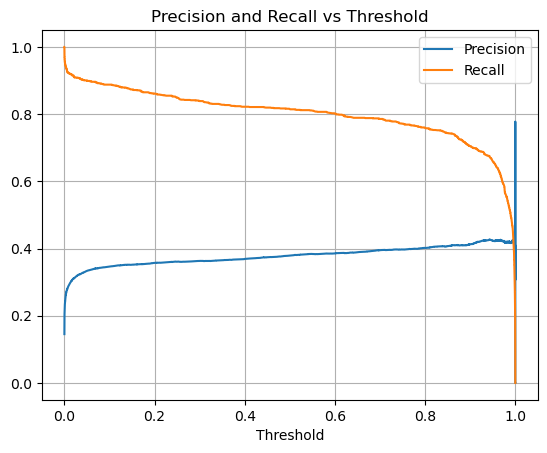

In [173]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(val_all[label], y_val_prob)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.grid()
plt.title('Precision and Recall vs Threshold')
plt.show()

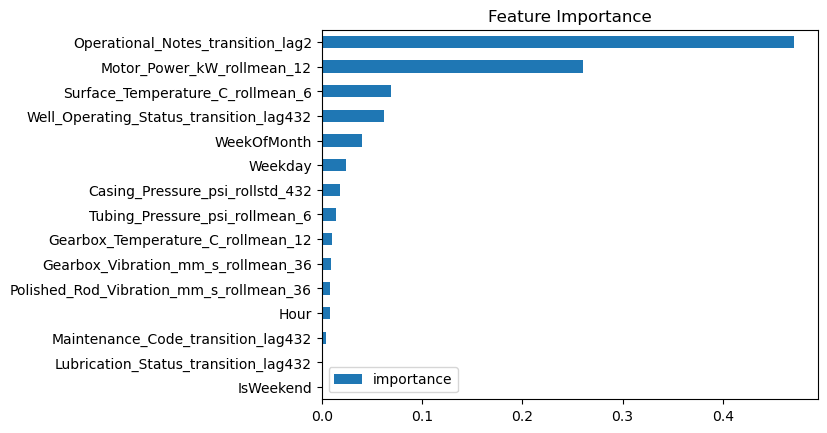

In [174]:
fi = pd.DataFrame(data = model.feature_importances_,
                 index = model.feature_names_in_,
                 columns = ['importance'])
fi.sort_values('importance').plot(kind= 'barh', title ='Feature Importance')
plt.show()

In [175]:
print(fi.sort_values('importance', ascending= False))

                                         importance
Operational_Notes_transition_lag2          0.471026
Motor_Power_kW_rollmean_12                 0.261012
Surface_Temperature_C_rollmean_6           0.069471
Well_Operating_Status_transition_lag432    0.062432
WeekOfMonth                                0.039685
Weekday                                    0.024335
Casing_Pressure_psi_rollstd_432            0.018048
Tubing_Pressure_psi_rollmean_6             0.014628
Gearbox_Temperature_C_rollmean_12          0.009799
Gearbox_Vibration_mm_s_rollmean_36         0.009475
Polished_Rod_Vibration_mm_s_rollmean_36    0.007818
Hour                                       0.007765
Maintenance_Code_transition_lag432         0.003877
Lubrication_Status_transition_lag432       0.000629
IsWeekend                                  0.000000


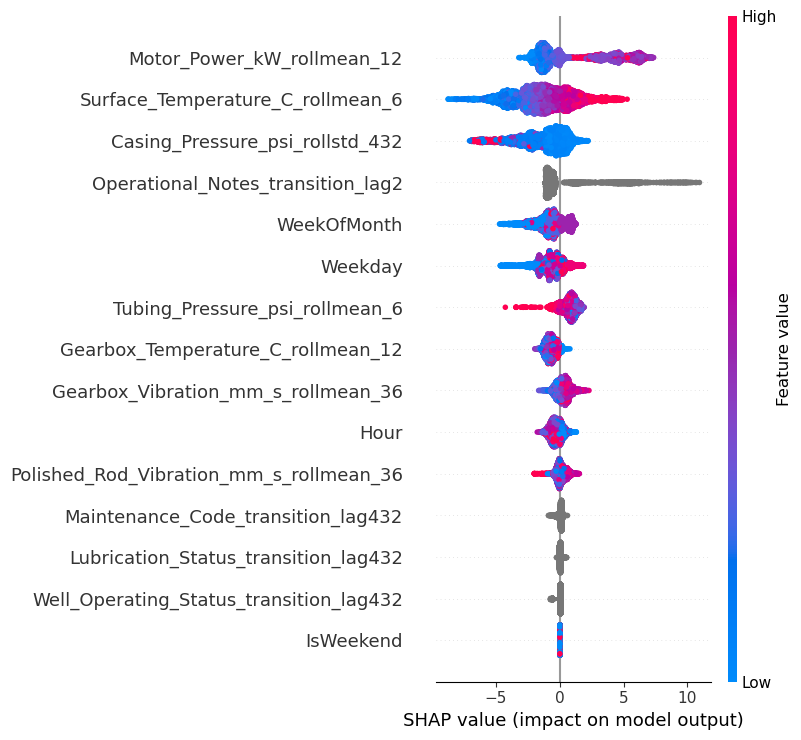

In [176]:
import shap
# Step 1: Create SHAP explainer
explainer = shap.Explainer(model)  # Works with XGBoost 1.5+
# If this fails, use: shap.TreeExplainer(model)

# Step 2: Compute SHAP values for your validation set
shap_values = explainer(val_all[final_features + time_vals])

# Step 3: Summary plot (global feature importance + direction)
shap.summary_plot(shap_values, val_all[final_features + time_vals])

In [177]:
fi_df = pd.DataFrame(fi).reset_index()

In [178]:
fi_df.sort_values(by = 'importance', ascending = True)

,index,importance
13,IsWeekend,0.000000
10,Lubrication_Status_transition_lag432,0.000629
9,Maintenance_Code_transition_lag432,0.003877
11,Hour,0.007765
2,Polished_Rod_Vibration_mm_s_rollmean_36,0.007818
6,Gearbox_Vibration_mm_s_rollmean_36,0.009475
4,Gearbox_Temperature_C_rollmean_12,0.009799
3,Tubing_Pressure_psi_rollmean_6,0.014628
5,Casing_Pressure_psi_rollstd_432,0.018048
12,Weekday,0.024335


## 1. Remove IsWeekend

In [179]:
fi_list = fi_df['index'].tolist().copy()

In [180]:
to_drop = ['IsWeekend']
wo_1 = [x for x in fi_list if x not in to_drop]

In [181]:
len(wo_1)

14

In [182]:
model.fit(sub_train_all[wo_1], sub_train_all['Monitoring_Alert'],
         verbose = 50)

y_val_pred = model.predict(val_all[wo_1])
y_val_prob = model.predict_proba(val_all[wo_1])[:, 1]

threshold = 0.3  # try different values
y_val_pred = (y_val_prob >= threshold).astype(int)

print("Classifacation Report: \n", classification_report(val_all[label], y_val_pred))
print("AUC:", roc_auc_score(val_all[label], y_val_prob))
print("Confusion Matrix:\n", confusion_matrix(val_all[label], y_val_pred))

Classifacation Report: 
               precision    recall  f1-score   support

         0.0       0.96      0.75      0.84      6974
         1.0       0.36      0.84      0.51      1185

    accuracy                           0.76      8159
   macro avg       0.66      0.79      0.68      8159
weighted avg       0.88      0.76      0.79      8159

AUC: 0.840924700424361
Confusion Matrix:
 [[5230 1744]
 [ 191  994]]


Droping the first varible was not very impactful.

## 2. Remove Maintenance_Code_transition_lag432 based on SHAP

#### Post Submission Adjustment 4
wo_2 was not using wo_1 for succeeding list

In [213]:
to_drop = ['Maintenance_Code_transition_lag432']
wo_2 = [x for x in wo_1 if x not in to_drop]

In [214]:
wo_2

['Motor_Power_kW_rollmean_12',
 'Surface_Temperature_C_rollmean_6',
 'Polished_Rod_Vibration_mm_s_rollmean_36',
 'Tubing_Pressure_psi_rollmean_6',
 'Gearbox_Temperature_C_rollmean_12',
 'Casing_Pressure_psi_rollstd_432',
 'Gearbox_Vibration_mm_s_rollmean_36',
 'Operational_Notes_transition_lag2',
 'Well_Operating_Status_transition_lag432',
 'Lubrication_Status_transition_lag432',
 'Hour',
 'Weekday',
 'WeekOfMonth']

In [215]:
len(wo_2)

13

In [202]:
model.fit(sub_train_all[wo_2], sub_train_all['Monitoring_Alert'],
         verbose = 50)

y_val_pred = model.predict(val_all[wo_2])
y_val_prob = model.predict_proba(val_all[wo_2])[:, 1]

threshold = 0.3  # try different values
y_val_pred = (y_val_prob >= threshold).astype(int)

print("Classifacation Report: \n", classification_report(val_all[label], y_val_pred))
print("AUC:", roc_auc_score(val_all[label], y_val_prob))
print("Confusion Matrix:\n", confusion_matrix(val_all[label], y_val_pred))

Classifacation Report: 
               precision    recall  f1-score   support

         0.0       0.97      0.74      0.84      6974
         1.0       0.36      0.85      0.51      1185

    accuracy                           0.76      8159
   macro avg       0.66      0.80      0.67      8159
weighted avg       0.88      0.76      0.79      8159

AUC: 0.838300789309055
Confusion Matrix:
 [[5178 1796]
 [ 173 1012]]


Same as before - was not very impactful

## 3. Remove Well_Operating_Status_transition_lag432

In [224]:
to_drop = ['Well_Operating_Status_transition_lag432']
wo_3 = [x for x in wo_2 if x not in to_drop]

In [230]:
wo_3

['Motor_Power_kW_rollmean_12',
 'Surface_Temperature_C_rollmean_6',
 'Polished_Rod_Vibration_mm_s_rollmean_36',
 'Tubing_Pressure_psi_rollmean_6',
 'Gearbox_Temperature_C_rollmean_12',
 'Casing_Pressure_psi_rollstd_432',
 'Gearbox_Vibration_mm_s_rollmean_36',
 'Operational_Notes_transition_lag2',
 'Lubrication_Status_transition_lag432',
 'Hour',
 'Weekday',
 'WeekOfMonth']

In [226]:
len(wo_3)

12

In [227]:
model.fit(sub_train_all[wo_3], sub_train_all['Monitoring_Alert'],
         verbose = 50)

y_val_pred = model.predict(val_all[wo_3])
y_val_prob = model.predict_proba(val_all[wo_3])[:, 1]

threshold = 0.3  # try different values
y_val_pred = (y_val_prob >= threshold).astype(int)

print("Classifacation Report: \n", classification_report(val_all[label], y_val_pred))
print("AUC:", roc_auc_score(val_all[label], y_val_prob))
print("Confusion Matrix:\n", confusion_matrix(val_all[label], y_val_pred))

Classifacation Report: 
               precision    recall  f1-score   support

         0.0       0.96      0.75      0.84      6974
         1.0       0.36      0.84      0.50      1185

    accuracy                           0.76      8159
   macro avg       0.66      0.79      0.67      8159
weighted avg       0.88      0.76      0.79      8159

AUC: 0.8375343500088938
Confusion Matrix:
 [[5223 1751]
 [ 195  990]]


## 4. Remove Hour

In [234]:
to_drop = ['Lubrication_Status_transition_lag432']
wo_4 = [x for x in wo_3 if x not in to_drop]

In [235]:
wo_4

['Motor_Power_kW_rollmean_12',
 'Surface_Temperature_C_rollmean_6',
 'Polished_Rod_Vibration_mm_s_rollmean_36',
 'Tubing_Pressure_psi_rollmean_6',
 'Gearbox_Temperature_C_rollmean_12',
 'Casing_Pressure_psi_rollstd_432',
 'Gearbox_Vibration_mm_s_rollmean_36',
 'Operational_Notes_transition_lag2',
 'Hour',
 'Weekday',
 'WeekOfMonth']

In [236]:
len(wo_4)

11

In [237]:
model.fit(sub_train_all[wo_4], sub_train_all['Monitoring_Alert'],
         verbose = 50)
y_val_pred = model.predict(val_all[wo_4])
y_val_prob = model.predict_proba(val_all[wo_4])[:, 1]

threshold = 0.3  # try different values
y_val_pred = (y_val_prob >= threshold).astype(int)

print("Classifacation Report: \n", classification_report(val_all[label], y_val_pred))
print("AUC:", roc_auc_score(val_all[label], y_val_prob))
print("Confusion Matrix:\n", confusion_matrix(val_all[label], y_val_pred))

Classifacation Report: 
               precision    recall  f1-score   support

         0.0       0.96      0.75      0.84      6974
         1.0       0.36      0.83      0.50      1185

    accuracy                           0.76      8159
   macro avg       0.66      0.79      0.67      8159
weighted avg       0.88      0.76      0.80      8159

AUC: 0.8363840860386802
Confusion Matrix:
 [[5245 1729]
 [ 202  983]]


From here, false negative is increasing, so we stop proceeding to the step 4, and step 3 is the final model selection. For the sake of illustration, smaller model with feature importance feature is attemped below.

## 4. Remove Features < 0.015 Importance

In [248]:
fi_df.sort_values(by = 'importance', ascending=False)

,index,importance
7,Operational_Notes_transition_lag2,0.471026
0,Motor_Power_kW_rollmean_12,0.261012
1,Surface_Temperature_C_rollmean_6,0.069471
8,Well_Operating_Status_transition_lag432,0.062432
14,WeekOfMonth,0.039685
12,Weekday,0.024335
5,Casing_Pressure_psi_rollstd_432,0.018048
3,Tubing_Pressure_psi_rollmean_6,0.014628
4,Gearbox_Temperature_C_rollmean_12,0.009799
6,Gearbox_Vibration_mm_s_rollmean_36,0.009475


In [249]:
feature_003 = fi_df[fi_df['importance'] > 0.015]['index']

model.fit(sub_train_all[list(feature_003)], sub_train_all['Monitoring_Alert'],
         verbose = 50)

y_val_pred = model.predict(val_all[feature_003])
y_val_prob = model.predict_proba(val_all[feature_003])[:, 1]

In [250]:
threshold = 0.3  # try different values
y_val_pred = (y_val_prob >= threshold).astype(int)

print("Classifacation Report: \n", classification_report(val_all[label], y_val_pred))
print("AUC:", roc_auc_score(val_all[label], y_val_prob))
print("Confusion Matrix:\n", confusion_matrix(val_all[label], y_val_pred))

Classifacation Report: 
               precision    recall  f1-score   support

         0.0       0.94      0.81      0.87      6974
         1.0       0.38      0.67      0.48      1185

    accuracy                           0.79      8159
   macro avg       0.66      0.74      0.68      8159
weighted avg       0.86      0.79      0.81      8159

AUC: 0.8153163225918088
Confusion Matrix:
 [[5658 1316]
 [ 386  799]]


It is shown that FN is even more increased and it is recommended to stick to the 1st model.

In [251]:
feature_003

0                  Motor_Power_kW_rollmean_12
1            Surface_Temperature_C_rollmean_6
5             Casing_Pressure_psi_rollstd_432
7           Operational_Notes_transition_lag2
8     Well_Operating_Status_transition_lag432
12                                    Weekday
14                                WeekOfMonth
Name: index, dtype: object

In [252]:
print("Selected variables: \n", wo_2)

Selected variables: 
 ['Motor_Power_kW_rollmean_12', 'Surface_Temperature_C_rollmean_6', 'Polished_Rod_Vibration_mm_s_rollmean_36', 'Tubing_Pressure_psi_rollmean_6', 'Gearbox_Temperature_C_rollmean_12', 'Casing_Pressure_psi_rollstd_432', 'Gearbox_Vibration_mm_s_rollmean_36', 'Operational_Notes_transition_lag2', 'Well_Operating_Status_transition_lag432', 'Lubrication_Status_transition_lag432', 'Hour', 'Weekday', 'WeekOfMonth']


#### Todo: Use models like LightGBM and average feature importance over multiple TimeSeriesSplit folds.

# 3. Hyper Parameter Tuning

## Time Series Cross Validation

In [253]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import roc_auc_score, make_scorer

# 1. Split 90% of training data for tuning
train_cv_data = train_all.loc[:split_point_].copy()

# 2. Ensure all categorical features are of type 'category'
# categorical_cols = [
#     'Operational_Notes_transition_lag2',
#     'Well_Operating_Status_lag_432',
#     'Lubrication_Status_lag_432',
#     'Maintenance_Code_lag_36'
# ]


for col in mi_features:
    if col in train_cv_data.columns:
        train_cv_data[col] = pd.Categorical(train_cv_data[col])

# 3. Define your features and label
X = train_cv_data[wo_2]  # wo_2 is your feature list
y = train_cv_data['Monitoring_Alert']

# 4. TimeSeriesSplit setup
tss = TimeSeriesSplit(n_splits=5, test_size=3700)

# 5. Define model with categorical support
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    enable_categorical=True,
    tree_method='hist'
)

# 6. Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9, 11],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 7. Use ROC AUC as scoring metric
scorer = make_scorer(roc_auc_score, needs_proba=True)

# 8. Grid search with time series cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring=scorer,
    cv=tss,
    verbose=1,
    n_jobs=-1
)

# 9. Fit grid search
grid_search.fit(X, y)

# 10. Output best model and params
print("Best ROC AUC Score:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

# 11. Extract the best model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Best ROC AUC Score: 0.9628143784301642
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}


In [254]:
!pip install joblib

In [255]:
import joblib
joblib.dump(best_model, 'xgb_final_model.pkl')

['xgb_final_model.pkl']

In [256]:
import json

# Get best params from grid search
best_params = grid_search.best_params_

# Save to JSON file
with open("best_xgb_params.json", "w") as f:
    json.dump(best_params, f)

In [257]:
# # Load the saved model
# loaded_model = joblib.load('xgb_final_model.pkl')

# # Use it
# y_pred = loaded_model.predict(X_new)

In [258]:
# with open("best_xgb_params.json", "r") as f:
#     loaded_params = json.load(f)

In [259]:
best_params = grid_search.best_params_

In [260]:
best_params

{'colsample_bytree': 0.8,
 'learning_rate': 0.01,
 'max_depth': 3,
 'n_estimators': 50,
 'subsample': 1.0}

## 4. Test Error Estimation and Test Data Prediction 

## Retrain and Obtain Estimated Validation Accuracy on Test Data

It is essential to fit the finalized best model to the **entire sub-training set (90%)** before estimating test error on the validation set (10%)

In [261]:
# categorical_cols = [
#     'Operational_Notes_transition_lag2',
#     'Well_Operating_Status_lag_432',
#     'Lubrication_Status_lag_432',
#     'Maintenance_Code_lag_36'
# ]
# for col in categorical_cols:
#     if col in train_all.columns:
#         train_all[col] = pd.Categorical(train_all[col])

In [262]:
train_cv_data = train_all.iloc[:split_point_]
hold_out_cv_data = train_all.iloc[split_point_:]

In [263]:
final_model = XGBClassifier(
    **best_params,
    random_state=42,
    eval_metric='logloss',
    enable_categorical=True,
    tree_method='hist'
)


final_model.fit(train_cv_data[wo_2], train_cv_data['Monitoring_Alert'],verbose = 50)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [264]:
X_holdout = hold_out_cv_data[wo_2]
y_holdout = hold_out_cv_data['Monitoring_Alert']

# 2. Predict probabilities and class labels
y_prob = final_model.predict_proba(X_holdout)[:, 1]
y_pred = final_model.predict(X_holdout)

In [265]:
# 3. Evaluate
threshold = 0.3
y_pred_custom = (y_prob >= threshold).astype(int)

print("\n🔍 AUC (custom threshold):", roc_auc_score(y_holdout, y_prob))
print("\n📋 Report (threshold=0.3):\n", classification_report(y_holdout, y_pred_custom))
print("\n🧮 Confusion Matrix:\n", confusion_matrix(y_holdout, y_pred_custom))


🔍 AUC (custom threshold): 0.917192826071454

📋 Report (threshold=0.3):
               precision    recall  f1-score   support

         0.0       0.98      0.88      0.93      3700
         1.0       0.40      0.82      0.54       379

    accuracy                           0.87      4079
   macro avg       0.69      0.85      0.73      4079
weighted avg       0.93      0.87      0.89      4079


🧮 Confusion Matrix:
 [[3244  456]
 [  69  310]]


The estimation of the test error is shown above.

## Retrain and Obtain Predicted Values from Test Data

The entire training data set (100%) is used for fitting the best model found, and prediction on the test data set is reported.

Note: entire data set obtained feature engineering at once to prevent any unnecesary NA creations due to lag/rolling.

In [266]:
# Apply feature enginnering to the entire data set, 
df_featured = generate_final_selected_features(df_imp, final_features)
# Convert relevant engineered categoreis into factor type 

# categorical_cols = [
#     'Operational_Notes_transition_lag2',
#     'Well_Operating_Status_lag_432',
#     'Lubrication_Status_lag_432',
#     'Maintenance_Code_lag_36'
# ]
for col in mi_features:
    if col in df_featured.columns:
        df_featured[col] = pd.Categorical(df_featured[col])
        
# Split train and test 
train_featured = df_featured.iloc[train.index]
test_featured = df_featured.iloc[test.index]

In [267]:
# Sanity check
test_featured.shape

(10197, 37)

In [268]:
train_featured.shape

(40787, 37)

In [269]:
final_model = XGBClassifier(
    **best_params,
    random_state=42,
    eval_metric='logloss',
    enable_categorical=True,
    tree_method='hist'
)


final_model.fit(train_featured[wo_2], train_featured['Monitoring_Alert'],verbose = 50)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [270]:
# 2. Predict probabilities and class labels
y_prob = final_model.predict_proba(test_featured[wo_2])[:, 1]
y_pred = final_model.predict(test_featured[wo_2])

In [271]:
# 3. Evaluate
threshold = 0.3
y_pred_custom = (y_prob >= threshold).astype(int)


In [272]:
len(y_pred_custom)

10197

In [273]:
# Save as CSV
np.savetxt("test_prediction_threshold_0.3.csv", y_pred_custom, delimiter=",", fmt="%.5f")